# TP01 — Parte 1: Ruido, outliers, discretización y normalización

**Bases de Datos Masivas (11088)** - 2° Cuatrimestre 2026

Gustavo An Contardi - 182818

## Ejercicio 1 — Manejo de ruido

Dataset: `calidad_aire.csv`

### 1a. Características y distribución de las variables

> ¿Qué características tienen las variables? ¿Cómo se distribuyen las variables?
> Verifique gráficamente utilizando un gráfico QQ. ¿Qué puede decir sobre esas
> distribuciones?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
aire = pd.read_csv("data/calidad_aire.csv", parse_dates=["fecha"])

aire["ts"] = aire["fecha"] + pd.to_timedelta(aire["hora"], unit="h")
aire = aire.sort_values("ts").reset_index(drop=True)

CONTAM = [c for c in aire.columns if c not in ("fecha", "hora", "ts")]

print(f"filas: {len(aire)}  |  columnas: {aire.shape[1]}")
print(f"período: {aire.ts.min()} → {aire.ts.max()}")
aire.head()

filas: 5484  |  columnas: 12
período: 2026-01-01 01:00:00 → 2026-08-18 12:00:00


,fecha,hora,co_centenario,no2_centenario,pm10_centenario,co_cordoba,no2_cordoba,pm10_cordoba,co_la_boca,no2_la_boca,pm10_la_boca,ts
0,2026-01-01,1,NaN,6.0,NaN,0.28,13.0,42.0,0.43,9.0,37.0,2026-01-01 01:00:00
1,2026-01-01,2,0.38,8.0,NaN,0.30,15.0,44.0,0.42,11.0,37.0,2026-01-01 02:00:00
2,2026-01-01,3,0.35,14.0,NaN,0.32,14.0,45.0,0.41,11.0,38.0,2026-01-01 03:00:00
3,2026-01-01,4,0.30,23.0,NaN,0.33,16.0,46.0,0.39,13.0,39.0,2026-01-01 04:00:00
4,2026-01-01,5,0.22,7.0,NaN,0.27,9.0,48.0,0.34,11.0,42.0,2026-01-01 05:00:00


El dataset calidad_aire.csv contiene 5.484 registros con mediciones horarias tomadas entre el 1 de enero y el 18 de agosto de 2026. Cada fila corresponde a una hora e incluye nueve variables numéricas: tres contaminantes (CO, NO₂ y PM10) medidos en tres estaciones de monitoreo de la Ciudad de Buenos Aires — Centenario, Córdoba y La Boca. Las dos columnas restantes, fecha y hora, identifican el momento de la medición.

### Unidades y escalas

Las nueve variables no están expresadas en la misma unidad. El monóxido de carbono
se mide en ppm (partes por millón), el dióxido de nitrógeno en ppb (partes por mil
millones) y el material particulado en µg/m³ (microgramos por metro cúbico). Las dos
primeras son proporciones; la tercera es una masa por unidad de volumen.

Esto explica las diferencias de rango entre variables. El CO se mueve entre 0,03 y
2,07 mientras que el NO₂ llega a 88, pero eso no significa que haya más NO₂ en el aire:
el ppb es mil veces más chico que el ppm, así que los números no son comparables
directamente.

En consecuencia, cualquier análisis que combine estas variables —una distancia, una
correlación entre contaminantes distintos o un método basado en varianza— requiere
normalizarlas antes. Comparar magnitudes crudas entre columnas de este dataset no tiene
sentido.

In [3]:
aire[CONTAM].describe().T

,count,mean,std,min,25%,50%,75%,max
co_centenario,5395.0,0.442,0.211,0.06,0.30,0.40,0.530,1.57
no2_centenario,5379.0,13.322,6.135,2.00,9.00,13.00,17.000,43.00
pm10_centenario,5092.0,22.065,9.353,6.00,15.00,20.00,27.000,60.00
co_cordoba,5484.0,0.645,0.333,0.03,0.38,0.59,0.853,2.07
no2_cordoba,5436.0,19.123,8.837,0.00,13.00,18.00,24.000,88.00
pm10_cordoba,5197.0,26.855,9.475,9.00,20.00,25.00,32.000,62.00
co_la_boca,5053.0,0.329,0.491,0.06,0.20,0.27,0.370,23.00
no2_la_boca,5071.0,25.156,9.983,5.00,18.00,24.00,31.000,73.00
pm10_la_boca,4702.0,25.693,11.623,3.00,17.00,24.00,33.000,74.00


### Datos faltantes

Ocho de las nueve variables presentan datos faltantes, en proporciones que van del 0,9 %
(`no2_cordoba`) al 14,3 % (`pm10_la_boca`). La única serie completa es `co_cordoba`.

Los faltantes no se reparten de manera pareja. Ordenando las estaciones por porcentaje
de nulos aparece un patrón claro.

Se advierten dos regularidades. La primera es que La Boca concentra los faltantes en sus
tres contaminantes, lo que apunta a un problema de la estación en su conjunto —cortes de
energía, interrupciones de la transmisión— y no a fallas independientes de cada sensor.
La segunda es que el PM10 es la variable con más faltantes en las tres estaciones, lo que
sugiere que ese instrumento en particular es el menos confiable de los tres.

Ninguna variable supera el 15 % de faltantes, así que descartar la información incompleta
no sería la mejor estrategia: implicaría perder registros que en el resto de las columnas
están completos.

In [4]:
pd.DataFrame({
    "nulos": aire[CONTAM].isna().sum(),
    "% nulos": (100 * aire[CONTAM].isna().mean()).round(1),
})

,nulos,% nulos
co_centenario,89,1.6
no2_centenario,105,1.9
pm10_centenario,392,7.1
co_cordoba,0,0.0
no2_cordoba,48,0.9
pm10_cordoba,287,5.2
co_la_boca,431,7.9
no2_la_boca,413,7.5
pm10_la_boca,782,14.3


In [5]:
s = aire["co_la_boca"]

print("mediana:", s.median(), "| media:", round(s.mean(), 3), "| std:", round(s.std(), 3))
print("valores > 2 ppm:", int((s > 2).sum()))
print()

# las 10 mediciones más altas, con su marca temporal
aire.loc[s.nlargest(10).index, ["ts", "co_la_boca", "no2_la_boca", "pm10_la_boca"]]

mediana: 0.27 | media: 0.329 | std: 0.491
valores > 2 ppm: 2



,ts,co_la_boca,no2_la_boca,pm10_la_boca
3629,2026-06-01 06:00:00,23.00,32.0,NaN
3630,2026-06-01 07:00:00,23.00,33.0,NaN
3607,2026-05-31 08:00:00,1.92,32.0,36.0
3608,2026-05-31 09:00:00,1.92,33.0,37.0
3609,2026-05-31 10:00:00,1.92,40.0,39.0
3606,2026-05-31 07:00:00,1.90,33.0,35.0
3893,2026-06-12 06:00:00,1.84,34.0,49.0
3605,2026-05-31 06:00:00,1.82,32.0,34.0
3892,2026-06-12 05:00:00,1.82,27.0,49.0
3891,2026-06-12 04:00:00,1.81,32.0,49.0


In [6]:
i = aire["co_la_boca"].idxmax()

aire.loc[i-6:i+6, ["ts", "co_la_boca", "no2_la_boca", "co_centenario", "co_cordoba"]]

,ts,co_la_boca,no2_la_boca,co_centenario,co_cordoba
3623,2026-06-01 00:00:00,0.68,33.0,1.01,0.87
3624,2026-06-01 01:00:00,NaN,33.0,1.06,0.91
3625,2026-06-01 02:00:00,NaN,34.0,1.09,0.91
3626,2026-06-01 03:00:00,NaN,35.0,1.06,0.87
3627,2026-06-01 04:00:00,NaN,33.0,0.97,0.81
3628,2026-06-01 05:00:00,NaN,31.0,0.87,0.69
3629,2026-06-01 06:00:00,23.00,32.0,0.74,0.64
3630,2026-06-01 07:00:00,23.00,33.0,0.70,0.73
3631,2026-06-01 08:00:00,0.85,34.0,0.78,0.85
3632,2026-06-01 09:00:00,0.82,32.0,0.86,0.90


### Un valor anómalo en `co_la_boca`

La variable `co_la_boca` presenta dos registros de 23 ppm. El valor es difícil de
sostener: la mediana de la serie es 0,27 ppm, el percentil 75 es 0,37 y la tercera
medición más alta de toda la serie es 1,92. Los dos registros están, entonces, unas
ochenta veces por encima del valor típico de su propia estación y doce veces por encima
del segundo máximo.

El resumen estadístico ya lo anticipaba. `co_la_boca` es la única de las tres series de
CO cuyo desvío estándar (0,491) supera a su media (0,329). En una variable que no puede
tomar valores negativos, esa relación es señal de que unos pocos valores extremos están
inflando la dispersión: al quitar únicamente el máximo, el desvío cae a 0,373.

Al examinar el contexto temporal aparecen tres elementos que apuntan en la misma
dirección. Los dos registros corresponden al 1 de junio de 2026 a las 06:00 y 07:00, y
están precedidos por cinco horas consecutivas sin dato (de 01:00 a 05:00): el sensor
estuvo fuera de servicio y el 23 fue lo primero que reportó al volver. A las 08:00 la
serie retoma valores normales (0,85 ppm), un salto brusco que no se corresponde con la
forma en que decae un episodio real de contaminación. Por último, el NO₂ de la misma
estación se mantuvo entre 31 y 35 ppb durante toda la madrugada, incluidas las dos horas
del pico, sin reaccionar. Dado que ambos contaminantes provienen de la combustión
vehicular y tienden a subir juntos —en las 22 horas en que `co_la_boca` superó 1,5 ppm el
NO₂ promedió 38,7 ppb contra 25,1 del promedio general—, un aumento de CO de esa magnitud
sin ninguna respuesta del NO₂ no resulta plausible.

Por lo anterior, los dos registros de 23 ppm se interpretan como un error del instrumento
y no como un evento real de contaminación. Corresponde aclarar que las otras dos
estaciones no muestran nada inusual a esa hora (0,74 y 0,64 ppm), pero ese dato por sí
solo no prueba nada: el CO es un contaminante de dispersión muy local y un episodio
acotado a pocas cuadras podría no registrarse en Centenario ni en Córdoba.

El análisis de la forma de las distribuciones se desarrolla a continuación, a partir de
los gráficos QQ.

# QQ-Plot

Esta herramienta compara los cuantiles de nuestra variable contra los de una normal teórica. Si la variable fuera normal, los puntos caerían sobre la recta roja. Cuanto más se despegan, más se aleja de la normalidad y la forma en que se despegan nos dice de qué manera.

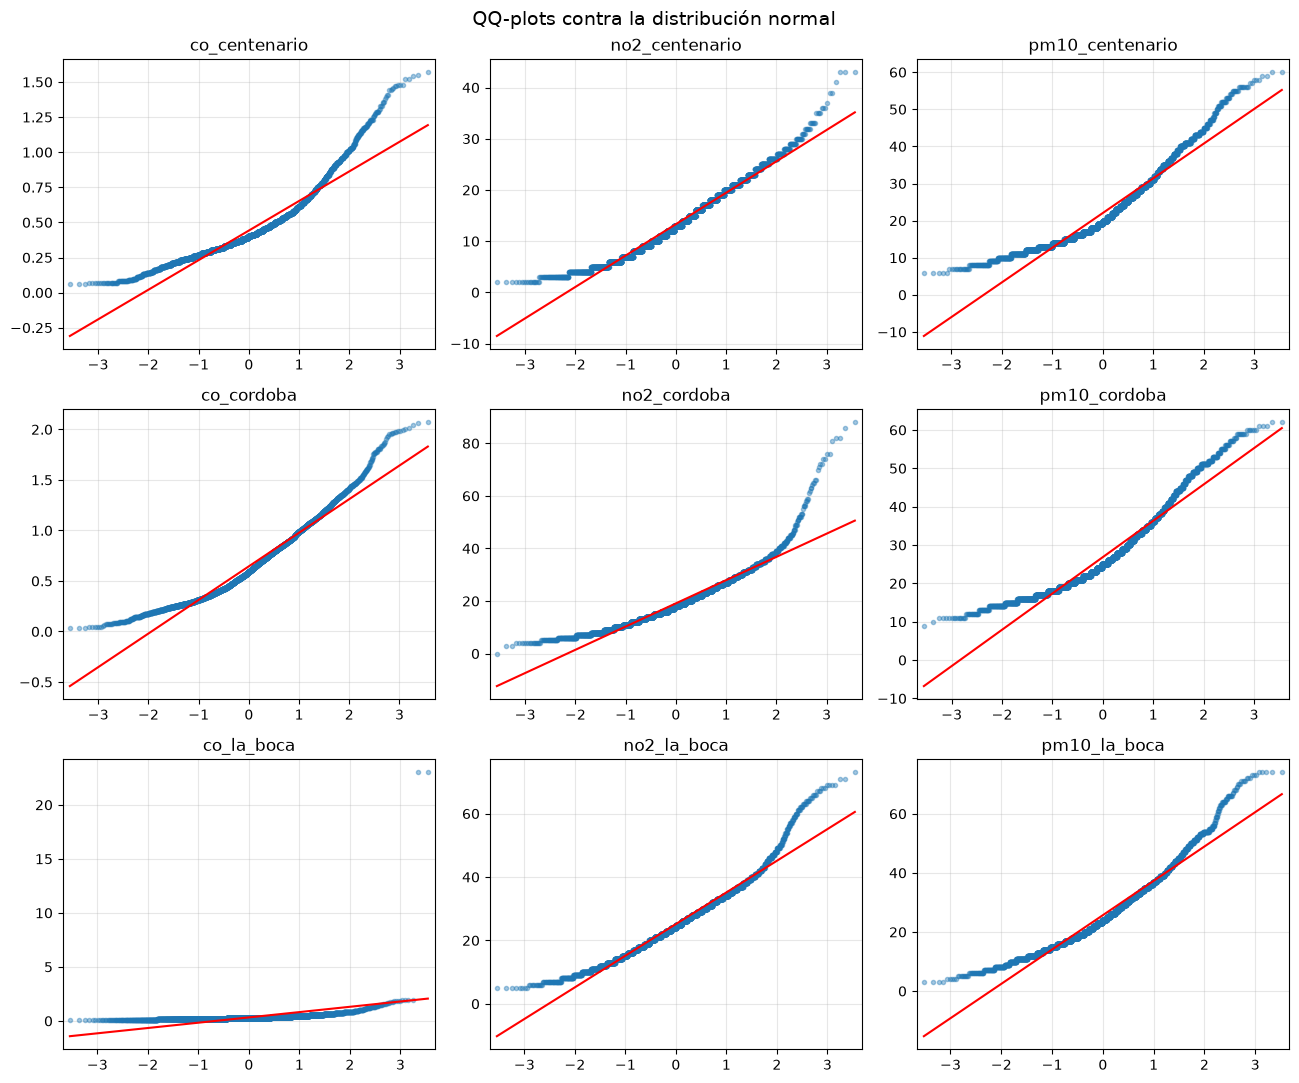

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(13, 11))

for col, ax in zip(CONTAM, axes.ravel()):
    sm.qqplot(aire[col].dropna().to_numpy(), line="s", ax=ax, markersize=3, alpha=.4)
    ax.set_title(col)
    ax.set_xlabel(""); ax.set_ylabel("")

fig.suptitle("QQ-plots contra la distribución normal", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
resumen = pd.DataFrame({
    "media": aire[CONTAM].mean(),
    "mediana": aire[CONTAM].median(),
    "asimetría": aire[CONTAM].apply(lambda s: stats.skew(s.dropna())),
    "curtosis": aire[CONTAM].apply(lambda s: stats.kurtosis(s.dropna())),
}).round(2)

resumen

,media,mediana,asimetría,curtosis
co_centenario,0.44,0.40,1.50,3.32
no2_centenario,13.32,13.00,0.55,0.14
pm10_centenario,22.07,20.00,1.04,0.81
co_cordoba,0.64,0.59,0.82,0.61
no2_cordoba,19.12,18.00,1.52,5.78
pm10_cordoba,26.86,25.00,0.99,0.61
co_la_boca,0.33,0.27,39.14,1796.29
no2_la_boca,25.16,24.00,0.83,1.59
pm10_la_boca,25.69,24.00,0.93,1.07


### Forma de las distribuciones

Ninguna de las nueve cae sobre la recta, y todas se desvían igual: la cola derecha se despega hacia arriba. Eso es asimetría positiva. Los coeficientes lo confirman, todos positivos, entre 0,55 y 1,52 en las ocho variables sin anomalías. Hay una verificación más simple: en las nueve, la media supera a la mediana.

Que el patrón se repita en nueve variables medidas por instrumentos distintos sugiere que no viene de los sensores sino del fenómeno. Son concentraciones: no pueden ser negativas, pero no tienen techo. Los valores se amontonan cerca de cero en las horas tranquilas y algunos episodios los disparan hacia arriba.

`co_la_boca` es un caso aparte. Su panel no sirve para evaluar la forma: el eje llega a 23 ppm y las demás observaciones quedan aplastadas contra la base. Sus coeficientes tampoco (asimetría 39,14, curtosis 1.796) porque describen dos puntos, no una distribución. Al excluirlos, la asimetría baja a 3,08 y el gráfico se parece al de las demás variables, lo que respalda el diagnóstico anterior.

### 1b. Suavizado por binning de igual frecuencia

> Realice un suavizado utilizando *binning* por *frecuencias iguales* y estime el valor
> del Bin por el cálculo de medias. Grafique las dos series resultantes y comente los
> resultados observados.


Se trabaja sobre `co_la_boca` con k = 5 bins. La elección de la variable responde a que es
la que presenta el valor anómalo detectado en 1a, lo que permite observar cómo se comporta
esta técnica frente a un extremo. El valor de k se toma dentro del rango que se explora en
1c, para que los resultados sean comparables.

Los bins se calculan sobre la serie completa (5.053 observaciones válidas) y el gráfico
muestra únicamente la primera semana de enero, que no tiene faltantes. Si los cortes se
calcularan sobre esa semana no representarían la distribución de la variable.

In [9]:
VAR = "co_la_boca"
K = 5

# bins por igual frecuencia sobre la serie completa
aire["bin_frec"] = pd.qcut(aire[VAR], q=K)

# cada valor se reemplaza por la media de su bin
aire["suave_EF"] = aire.groupby("bin_frec", observed=True)[VAR].transform("mean")

# cómo quedaron los bins
aire.groupby("bin_frec", observed=True)[VAR].agg(["count", "min", "max", "mean"]).round(3)

,count,min,max,mean
bin_frec,,,,
"(0.059, 0.19]",1053,0.06,0.19,0.161
"(0.19, 0.24]",1044,0.20,0.24,0.220
"(0.24, 0.3]",1029,0.25,0.30,0.272
"(0.3, 0.41]",930,0.31,0.41,0.351
"(0.41, 23.0]",997,0.42,23.00,0.660


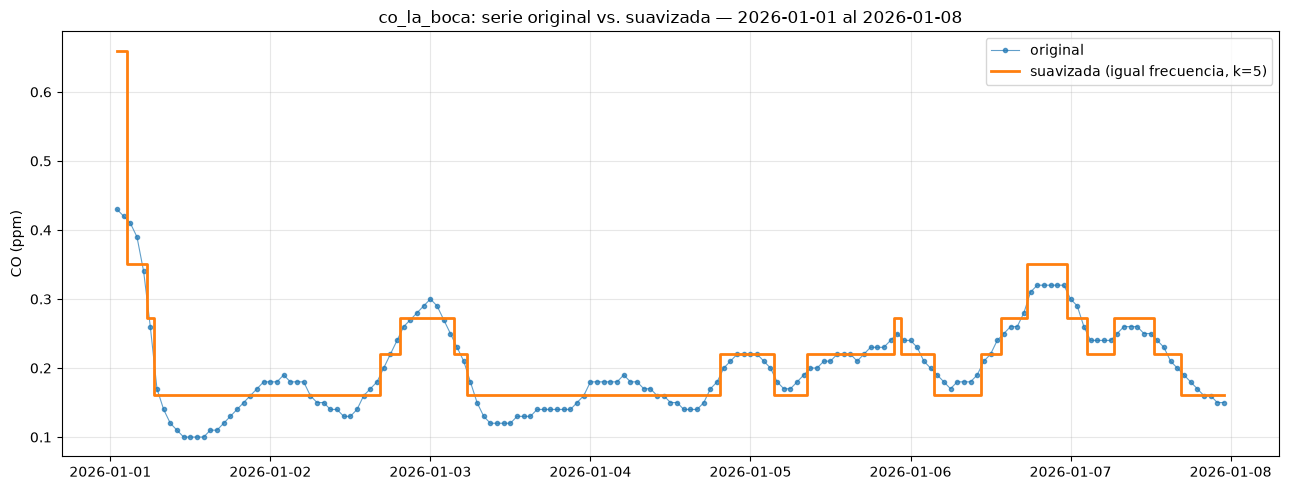

In [10]:
INI, FIN = "2026-01-01", "2026-01-08"
v = aire[(aire.ts >= INI) & (aire.ts < FIN)]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(v.ts, v[VAR], marker=".", lw=.8, alpha=.7, label="original")
ax.step(v.ts, v.suave_EF, where="mid", lw=2, label=f"suavizada (igual frecuencia, k={K})")
ax.set_ylabel("CO (ppm)")
ax.set_title(f"{VAR}: serie original vs. suavizada — {INI} al {FIN}")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
print("std original :", round(aire[VAR].std(), 4))
print("std suavizada:", round(aire["suave_EF"].std(), 4))
print("máx original :", aire[VAR].max(), "→ suavizado:", round(aire["suave_EF"].max(), 3))

std original : 0.4911
std suavizada: 0.1751
máx original : 23.0 → suavizado: 0.66


**Resultados**

Los cinco bins reciben entre 930 y 1.053 observaciones, como es esperable en un criterio por frecuencias. Sus anchos, en cambio, son muy distintos: los cuatro primeros cubren entre 0,05 y 0,13 ppm, mientras que el último abarca de 0,42 a 23 ppm. Esa es la
característica del método: los bins se angostan donde los datos se amontonan y se ensanchan donde escasean.

De ahí se desprende el resultado más relevante. El registro de 23 ppm cae en el último bin junto a otras 996 observaciones, y al reemplazarse por la media del bin queda convertido en 0,66 ppm. El valor extremo no se elimina ni se trata de manera especial:
queda diluido por el peso de los demás valores del bin. El desvío estándar de la serie cae de 0,491 a 0,175, una reducción del 64 %.

El costo es la pérdida de resolución. La serie suavizada solo puede tomar cinco valores, y en el gráfico el ciclo diario deja de verse como una curva para convertirse en una escalera de cinco niveles. El suavizado conserva el nivel general de la serie —se distingue cuándo sube y cuándo baja— pero pierde la magnitud de cada variación.

En síntesis, el binning por frecuencias iguales resulta robusto frente a valores extremos, ya que la posición de los cortes depende de la cantidad de observaciones y no de su magnitud. Un único valor 85 veces superior a la mediana no desplaza los límites de los bins. Esta propiedad se contrasta en 1c con el criterio de igual ancho.

### 1c. Suavizado por extremos con bins de igual ancho

> Utilizando suavizado por extremos calcular los bins con *anchos iguales* de 2 a 10 y
> comparar los resultados gráficamente. ¿Qué ocurre conforme el bin aumenta?

In [12]:
def suavizar_extremos(serie, k):
    """Binning por igual ancho con suavizado por extremos.

    Cada valor se reemplaza por el mínimo o el máximo observado dentro de su bin,
    según cuál de los dos le quede más cerca.
    """
    b = pd.cut(serie, bins=k)                    # bins de igual ancho
    g = serie.groupby(b, observed=True)
    lo = g.transform("min")                      # extremo inferior de cada bin
    hi = g.transform("max")                      # extremo superior
    return pd.Series(
        np.where((serie - lo).abs() <= (hi - serie).abs(), lo, hi),
        index=serie.index,
    )

En el suavizado por extremos se toman el mínimo y el máximo de cada bin como límites, y
cada valor se reemplaza por el que le queda más cerca. Es distinto de 1b: allá los valores
se iban al centro del bin, acá se van a los bordes.

Lo apliqué sobre dos variables. `co_cordoba` no tiene anomalías y `co_la_boca` tiene el
valor extremo que encontré en 1a. Comparar las dos es lo que contesta la pregunta.

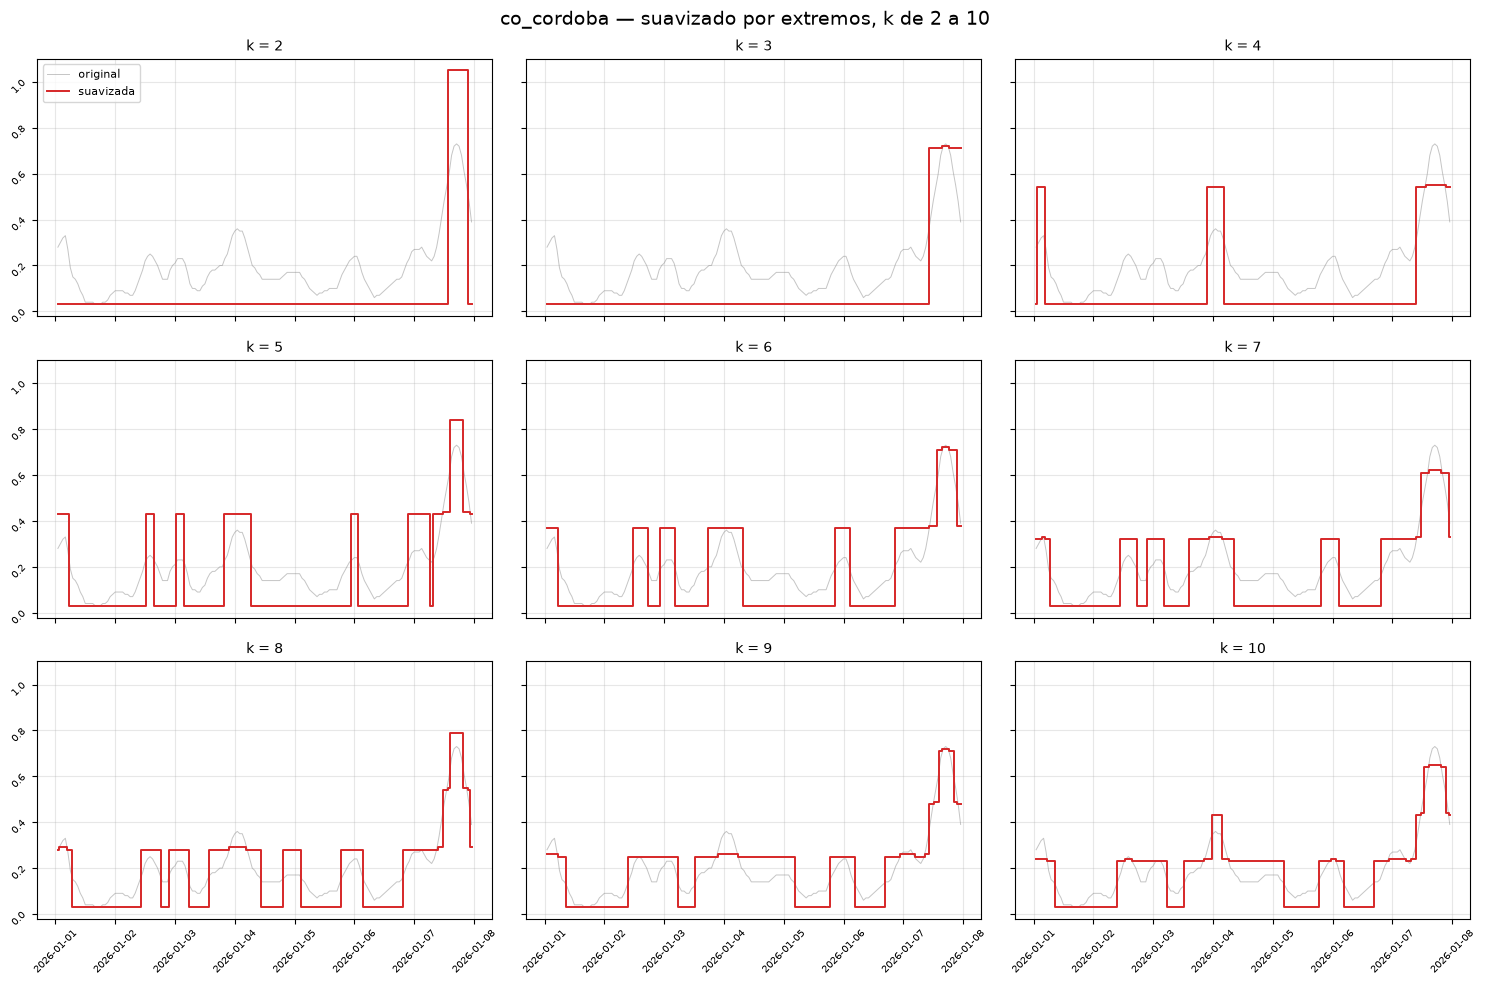

In [13]:
VAR = "co_cordoba"
INI, FIN = "2026-01-01", "2026-01-08"

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)

for k, ax in zip(range(2, 11), axes.ravel()):
    aire["tmp"] = suavizar_extremos(aire[VAR], k)
    v = aire[(aire.ts >= INI) & (aire.ts < FIN)]
    ax.plot(v.ts, v[VAR], lw=.7, alpha=.45, color="tab:gray", label="original")
    ax.step(v.ts, v.tmp, where="mid", lw=1.4, color="tab:red", label="suavizada")
    ax.set_title(f"k = {k}", fontsize=10)
    ax.tick_params(labelrotation=45, labelsize=7)

axes[0, 0].legend(fontsize=8)
fig.suptitle(f"{VAR} — suavizado por extremos, k de 2 a 10", fontsize=14)
plt.tight_layout()
plt.show()

**Serie sin anomalías (`co_cordoba`)**

Conforme k aumenta, el suavizado se debilita. Los niveles pasan de 4 a 20, o sea dos por
bin, lo que confirma que todos los bins reciben datos. Los escalones se van achicando y la
serie suavizada se pega cada vez más a la original. El error absoluto medio lo confirma:
baja de 0,288 con k = 2 a 0,046 con k = 10.

El reparto también mejora. Con k = 2 el primer bin se lleva el 88,1 % de las observaciones
y con k = 10 baja al 5,9 %. Esto viene de la asimetría positiva que vi en 1a: con pocos
bins de igual ancho los datos se amontonan en los primeros tramos y los últimos quedan
casi vacíos.

Llevado al extremo, si k fuera igual a la cantidad de observaciones cada valor sería su
propio bin y el suavizado no haría nada. Así que subir k no sale gratis: se gana fidelidad
pero se pierde el efecto que uno buscaba.

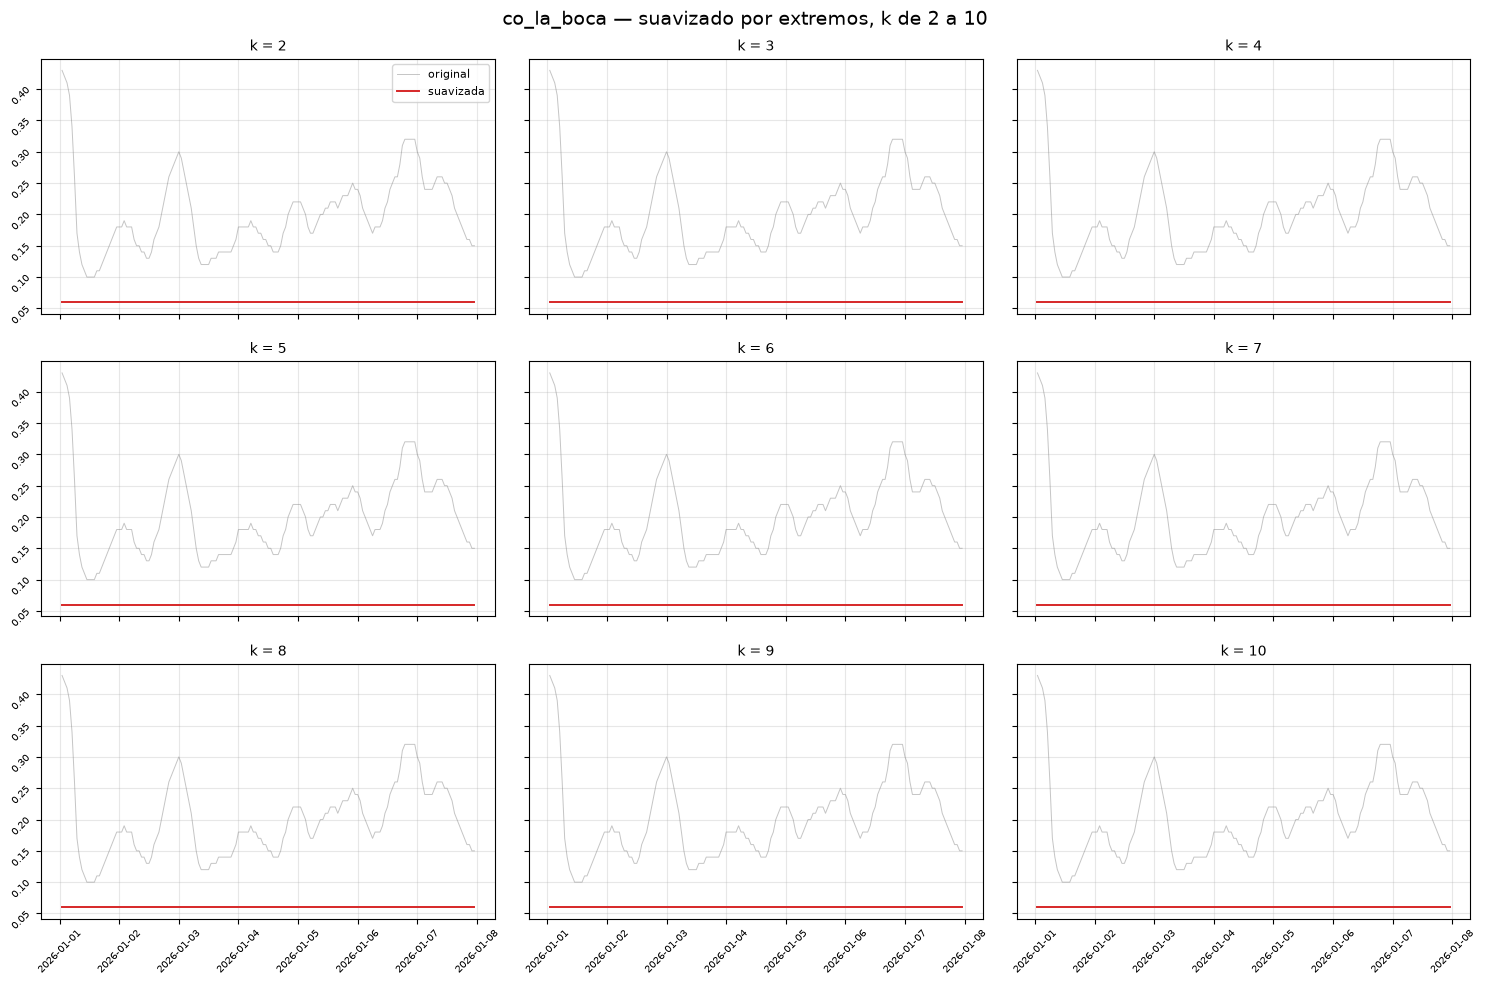

In [14]:
VAR = "co_la_boca"
INI, FIN = "2026-01-01", "2026-01-08"

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)

for k, ax in zip(range(2, 11), axes.ravel()):
    aire["tmp"] = suavizar_extremos(aire[VAR], k)
    v = aire[(aire.ts >= INI) & (aire.ts < FIN)]
    ax.plot(v.ts, v[VAR], lw=.7, alpha=.45, color="tab:gray", label="original")
    ax.step(v.ts, v.tmp, where="mid", lw=1.4, color="tab:red", label="suavizada")
    ax.set_title(f"k = {k}", fontsize=10)
    ax.tick_params(labelrotation=45, labelsize=7)

axes[0, 0].legend(fontsize=8)
fig.suptitle(f"{VAR} — suavizado por extremos, k de 2 a 10", fontsize=14)
plt.tight_layout()
plt.show()

**Serie con un valor extremo (`co_la_boca`)**

Acá pasa algo distinto: no cambia nada. Los nueve valores de k dan el mismo resultado.
Tres niveles, un error absoluto medio de 0,2503 y el 100 % de los datos en el primer bin.
Los nueve gráficos son idénticos.

La razón está en cómo se arman los bins de igual ancho. La variable va de 0,06 a 23 ppm,
así que incluso con k = 10 el primer bin llega hasta 2,35. Como la segunda medición más
alta es 1,92, las 5.051 observaciones válidas caen todas ahí y los dos registros de 23
quedan solos en el último bin. Los del medio quedan vacíos. Subdividir más fino un rango
donde no hay datos no sirve de nada.

Los tres niveles además están muy desbalanceados: 4.981 observaciones (98,6 %) se
reemplazan por 0,06 ppm, que es el mínimo de la serie. El suavizado no está reduciendo el
ruido, está anulando la variable. En la ventana que grafiqué, donde los valores originales
van de 0,10 a 0,43 ppm, la serie suavizada es una recta.

Con el valor anómalo pasa lo opuesto que en 1b. Como queda solo en su bin, su mínimo y su
máximo son él mismo, así que se reemplaza por 23 y no se mueve. Con frecuencias iguales
había quedado absorbido en 0,66 ppm.

In [15]:
filas = []
for var in ["co_cordoba", "co_la_boca"]:
    s = aire[var]
    for k in range(2, 11):
        sm = suavizar_extremos(s, k)
        vc = pd.cut(s, bins=k).value_counts().sort_index()
        filas.append({
            "variable": var,
            "k": k,
            "niveles": sm.nunique(),
            "% en el bin 1": round(100 * vc.iloc[0] / vc.sum(), 1),
            "MAE vs original": round((sm - s).abs().mean(), 4),
        })

pd.DataFrame(filas).pivot(index="k", columns="variable",
                          values=["niveles", "% en el bin 1", "MAE vs original"])

niveles            % en el bin 1            MAE vs original  \
variable co_cordoba co_la_boca    co_cordoba co_la_boca      co_cordoba   
k                                                                         
2               4.0        3.0          88.1      100.0           0.288   
3               6.0        3.0          62.0      100.0           0.186   
4               8.0        3.0          45.1      100.0           0.135   
5              10.0        3.0          32.9      100.0           0.098   
6              12.0        3.0          24.5      100.0           0.079   
7              14.0        3.0          17.8      100.0           0.066   
8              16.0        3.0          12.5      100.0           0.057   
9              18.0        3.0           8.1      100.0           0.051   
10             20.0        3.0           5.9      100.0           0.046   

                     
variable co_la_boca  
k                    
2              0.25  
3              0.25  
4              0.25  
5              0.25  
6              0.25  
7              0.25  
8              0.25  
9              0.25  
10             0.25

**Conclusión**

Qué ocurre conforme aumenta el bin depende de la distribución. En una serie sin valores
extremos, subir k reduce el suavizado de forma gradual y previsible. Cuando hay un valor
muy alejado del resto, el criterio de igual ancho queda inutilizado en todo el rango que
probé, porque los cortes salen del mínimo y el máximo y entonces una sola observación
define dónde caen todos los límites.

Esto confirma por contraste lo de 1b. Frecuencias iguales arma los cortes según cuántas
observaciones hay y aguanta bien estos casos; igual ancho los arma según el rango y es
muy sensible. Con la asimetría que tienen estas variables conviene el primero, y si se
quisiera usar el segundo habría que tratar antes los valores anómalos.

### 1d. Un caso de aplicación: la escala Beaufort

> Encuentre un caso de aplicación de *binning*, consiga datos para probar un suavizado por
> *binning* con alguna de las variantes presentadas. Justifique la elección del conjunto de
> datos y comente en qué contribuye la técnica.

**El caso**

La meteorología viene haciendo binning sobre la velocidad del viento desde hace dos siglos.
Ningún parte meteorológico dice "viento de 23,7 km/h": dice "brisa moderada", o directamente
usa un número de fuerza. Eso es la escala Beaufort, y es un binning hecho y derecho: doce
categorías con cortes fijos en km/h.

Se usa por dos motivos. El primero es que la medición instantánea es muy ruidosa, porque el
viento sopla a ráfagas. El segundo es que las decisiones que se toman con ese dato (sacar
una alerta, cerrar un puerto, demorar vuelos) dependen de umbrales, no del valor exacto. Si
el corte para emitir alerta está en 50 km/h, da lo mismo que el anemómetro marque 63 o 68.


**Los datos**

Usé la variable `vel_viento` de `clima_smn.csv`, quedándome con la estación BASE MARAMBIO
(573 observaciones horarias en 24 días).

La elegí por dos razones. Una es que es la más ventosa de las 40 estaciones del dataset:
media de 31,8 km/h, desvío de 18,9 y un máximo de 100. Eso importa porque con vientos suaves
solo se poblarían tres o cuatro niveles de la escala y la comparación no mostraría nada. Acá
se pueblan once.

La otra es que la serie es realmente ruidosa. De una hora a la otra el viento cambia 5,27
km/h en promedio, y en un caso saltó 73 km/h en una sola hora. Es exactamente el tipo de
señal donde suavizar tiene sentido.

El dato que traje de afuera es la escala en sí, que no está en el CSV. Eso es lo que
permite comparar los dos criterios del TP contra un tercero diseñado por gente del dominio.

In [16]:
clima = pd.read_csv("data/clima_smn.csv", parse_dates=["fecha"])
clima["ts"] = clima["fecha"] + pd.to_timedelta(clima["hora"], unit="h")

ESTACION = "BASE MARAMBIO"
est = clima[clima.estacion_meteorologica == ESTACION].sort_values("ts").reset_index(drop=True)
viento = est.vel_viento.dropna()

print(f"{ESTACION}: {len(viento)} observaciones")
print(f"media {viento.mean():.1f} | desvío {viento.std():.1f} | máx {viento.max():.0f} km/h")
print(f"variación media hora a hora: {est.vel_viento.diff().abs().mean():.2f} km/h")

BASE MARAMBIO: 573 observaciones
media 31.8 | desvío 18.9 | máx 100 km/h
variación media hora a hora: 5.27 km/h


In [17]:
# Escala Beaufort, en km/h (fuerzas 0 a 12)
BEAUFORT = [0, 1, 6, 12, 20, 29, 39, 50, 62, 75, 89, 103, 118]

bins_beaufort = pd.cut(viento, bins=BEAUFORT, right=False)
K = int((bins_beaufort.value_counts() > 0).sum())   # niveles Beaufort con datos

criterios = {
    "igual ancho":      pd.cut(viento, bins=K),
    "igual frecuencia": pd.qcut(viento, q=K, duplicates="drop"),
    "Beaufort":         bins_beaufort,
}

filas = []
for nombre, b in criterios.items():
    suave = viento.groupby(b, observed=True).transform("mean")
    vc = b.value_counts().sort_index()
    vc = vc[vc > 0]
    filas.append({
        "criterio": nombre,
        "bins con datos": len(vc),
        "n mínimo": vc.min(),
        "n máximo": vc.max(),
        "ancho mínimo": round(min(i.right - i.left for i in vc.index), 1),
        "ancho máximo": round(max(i.right - i.left for i in vc.index), 1),
        "MAE": round((suave - viento).abs().mean(), 3),
    })

pd.DataFrame(filas).set_index("criterio")

,bins con datos,n mínimo,n máximo,ancho mínimo,ancho máximo,MAE
criterio,,,,,,
igual ancho,11,2,123,9.1,9.2,2.096
igual frecuencia,11,35,69,2.0,39.0,1.787
Beaufort,11,2,140,1.0,14.0,2.238


In [18]:
# Con pocos bins, igual frecuencia agrupa velocidades incompatibles entre sí
print("último bin por igual frecuencia (k=7):", pd.qcut(viento, q=7).cat.categories[-1])
print("equivalente Beaufort de 52 km/h : fuerza 7 (temporal moderado)")
print("equivalente Beaufort de 100 km/h: fuerza 10 (temporal fuerte)")

último bin por igual frecuencia (k=7): (52.0, 100.0]
equivalente Beaufort de 52 km/h : fuerza 7 (temporal moderado)
equivalente Beaufort de 100 km/h: fuerza 10 (temporal fuerte)


**Comparación**

Apliqué los tres criterios con la misma cantidad de bins (11, que son los niveles Beaufort
con datos) y suavicé por medias en los tres casos.

| Criterio | MAE | n por bin | ancho de bin |
| --- | --- | --- | --- |
| Igual ancho | 2,096 | 2 a 123 | 9,1 a 9,2 |
| Igual frecuencia | 1,787 | 35 a 69 | 2,0 a 39,0 |
| Beaufort | 2,238 | 2 a 140 | 1 a 14 |

Cada uno mantiene fija una cosa distinta. El de igual ancho fija el ancho y deja que la
cantidad de datos varíe (de 2 a 123 observaciones por bin). El de igual frecuencia fija la
cantidad y deja variar el ancho, que va de 2 a 39 km/h. Beaufort no fija ninguna de las dos:
sus anchos crecen de 1 a 14 km/h a medida que sube la escala. Eso tiene una razón física,
la fuerza que ejerce el viento crece con el cuadrado de la velocidad, así que cada escalón
representa un salto parecido de fuerza aunque no de velocidad.

Lo que más me llamó la atención es que el criterio con menos error es el que nadie usa. Por
MAE gana igual frecuencia (1,787) y Beaufort queda último (2,238), y sin embargo Beaufort es
el estándar internacional.

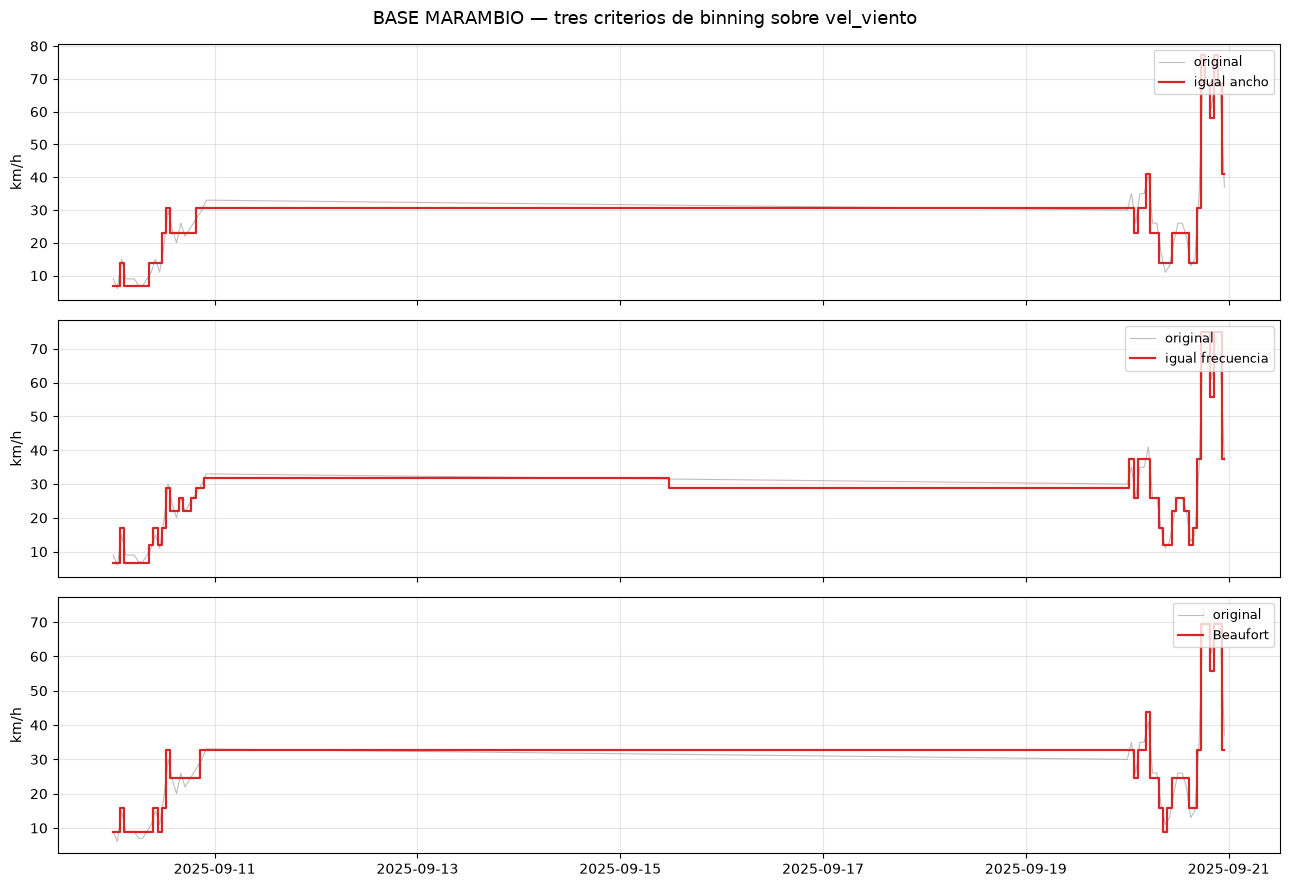

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
dia = est[est.fecha.isin(est.fecha.unique()[:2])]      # dos días

for (nombre, b), ax in zip(criterios.items(), axes):
    suave = viento.groupby(b, observed=True).transform("mean")
    ax.plot(dia.ts, dia.vel_viento, lw=.8, alpha=.5, color="tab:gray", label="original")
    ax.step(dia.ts, suave.reindex(dia.index), where="mid", lw=1.6,
            color="tab:red", label=nombre)
    ax.set_ylabel("km/h")
    ax.legend(loc="upper right", fontsize=9)

fig.suptitle(f"{ESTACION} — tres criterios de binning sobre vel_viento", fontsize=13)
plt.tight_layout()
plt.show()

**Por qué pasa eso**

Se ve mejor bajando la cantidad de bins. Con k = 7, el último bin del criterio por igual
frecuencia queda de 52 a 100 km/h. Ahí adentro conviven un viento de fuerza 7 y uno de
fuerza 10, o sea un temporal moderado y uno capaz de arrancar árboles. Estadísticamente el
bin está perfecto, tiene la misma cantidad de casos que los demás. Operativamente no sirve
para nada, porque los dos extremos exigen decisiones distintas.

El problema es que igual frecuencia ubica los cortes según dónde se acumulan los datos, y
los umbrales que importan no tienen por qué estar ahí. En Marambio los vientos fuertes son
frecuentes, así que el criterio los mete todos juntos. En una estación de viento suave, los
mismos 60 km/h caerían solos en el último bin.

**En qué contribuye la técnica**

El binning acá aporta dos cosas. Baja el ruido de las ráfagas, que es lo que se buscaba en
1b y 1c. Y convierte una variable continua en una categórica ordenada, que se puede
comunicar, comparar entre estaciones y usar como umbral de decisión.

Pero la comparación deja algo más claro, y es que no hay un criterio mejor en abstracto.
Depende de para qué. Si el objetivo es reconstruir la señal con el menor error posible,
igual frecuencia es el mejor de los tres, como ya se había visto en 1b. Si el objetivo es
tomar decisiones sobre umbrales, hace falta un criterio definido por el dominio aunque
suavice peor. Los dos métodos del TP optimizan una propiedad estadística; Beaufort optimiza
la utilidad de las categorías, y esa no se mide con MAE.

## Ejercicio 2 — Detección de outliers

> Utilizando el conjunto de datos *clima_smn.csv* analice los siguientes requerimientos.


### 2a. Primera exploración: qué variables tienen observaciones etiquetables como outliers

> A partir de una primera exploración qué variables poseen observaciones que pueden etiquetarse como outliers.
>


#### Carga de datos

In [20]:
clima = pd.read_csv("data/clima_smn.csv", parse_dates=["fecha"])

# mismo criterio que en el ejercicio 1: un timestamp único por observación
clima["ts"] = clima["fecha"] + pd.to_timedelta(clima["hora"], unit="h")
clima = clima.sort_values(["estacion_meteorologica", "ts"]).reset_index(drop=True)

# hora queda afuera: es el sello temporal del registro, no una medición
NUM = ["temperatura", "humedad", "presion", "dir_viento", "vel_viento"]

print(f"filas: {len(clima)}  |  columnas: {clima.shape[1]}")
print(f"período: {clima.ts.min().date()} → {clima.ts.max().date()}")
print(f"estaciones: {clima.estacion_meteorologica.nunique()}")
clima.head()

filas: 23019  |  columnas: 10
período: 2025-09-10 → 2026-08-20
estaciones: 40


,fecha,hora,estacion_meteorologica,temporada,temperatura,humedad,presion,dir_viento,vel_viento,ts
0,2025-09-10,0,AEROPARQUE AERO,Primavera,15.6,80.0,1016.7,340.0,9.0,2025-09-10 00:00:00
1,2025-09-10,1,AEROPARQUE AERO,Primavera,15.3,84.0,1016.1,340.0,9.0,2025-09-10 01:00:00
2,2025-09-10,2,AEROPARQUE AERO,Primavera,15.1,85.0,1015.8,340.0,9.0,2025-09-10 02:00:00
3,2025-09-10,3,AEROPARQUE AERO,Primavera,14.8,85.0,1015.2,340.0,9.0,2025-09-10 03:00:00
4,2025-09-10,4,AEROPARQUE AERO,Primavera,15.0,74.0,1015.0,320.0,17.0,2025-09-10 04:00:00


In [21]:
display(clima[NUM].describe().T)

pd.DataFrame({
    "nulos": clima[NUM].isna().sum(),
    "% nulos": (100 * clima[NUM].isna().mean()).round(1),
})


,count,mean,std,min,25%,50%,75%,max
temperatura,23019.0,16.112,8.961,-26.0,10.2,16.6,22.5,42.6
humedad,23014.0,68.704,21.191,6.0,53.0,72.0,87.0,100.0
presion,21293.0,1012.287,9.392,963.2,1006.9,1012.9,1017.6,1038.7
dir_viento,23017.0,192.942,167.195,0.0,90.0,180.0,270.0,990.0
vel_viento,23017.0,13.505,10.003,0.0,7.0,11.0,19.0,100.0


,nulos,% nulos
temperatura,0,0.0
humedad,5,0.0
presion,1726,7.5
dir_viento,2,0.0
vel_viento,2,0.0


In [22]:
# Antes de aplicar un criterio de outliers conviene saber si cada columna es
# realmente un continuo. Miro cuántos valores distintos toma y con qué paso
# avanzan esos valores: un continuo tiene muchos valores y pasos irregulares,
# una grilla tiene pocos y siempre el mismo paso.
filas = []
for v in NUM:
    u = np.sort(clima[v].dropna().unique())
    d = pd.Series(np.diff(u))          # distancia entre valores consecutivos
    paso = d.mode().iloc[0]
    filas.append({
        "variable": v,
        "n distintos": len(u),
        "mín": u.min(),
        "máx": u.max(),
        "paso mínimo": round(d.min(), 3),
        "paso más frecuente": round(paso, 3),
        "% en el paso frecuente": round(100 * (d == paso).mean(), 1),
    })

pd.DataFrame(filas).set_index("variable")

,n distintos,mín,máx,paso mínimo,paso más frecuente,% en el paso frecuente
variable,,,,,,
temperatura,584,-26.0,42.6,0.1,0.1,31.9
humedad,95,6.0,100.0,1.0,1.0,100.0
presion,645,963.2,1038.7,0.1,0.1,57.8
dir_viento,38,0.0,990.0,10.0,10.0,97.3
vel_viento,49,0.0,100.0,1.0,2.0,79.2


#### Qué tipo de variable es cada una

Antes de aplicar cualquier criterio miré qué son estas columnas, porque el dataset tiene
cinco variables numéricas pero no son cinco variables del mismo tipo.

`hora` la dejé afuera del análisis. No es una medición, es el horario en que se tomó el
registro, y está repartida parejo por diseño: 24 observaciones por día y por estación. Con
esa distribución ningún criterio la va a marcar nunca. La uso más adelante, en 2d, para
ubicar dónde caen los outliers, que es el papel que le corresponde.

De las cinco que quedan, temperatura y presión se comportan como continuas: 584 y 645
valores distintos, con paso de 0,1 en su unidad. La humedad toma 95 valores enteros y está
acotada entre 0 y 100 por definición. Llega a 100 en 205 registros, y ese no es un valor
anómalo sino el techo de la variable: el aire saturado no puede tener más de 100 % de
humedad relativa. La velocidad del viento toma 49 valores y arranca en cero, que también es
un piso real.

`dir_viento` es el caso distinto. Toma 38 valores y el 97,3 % de los saltos entre valores
consecutivos es exactamente 10. No es un continuo, es una grilla de 10 en 10 grados.

In [23]:
# Los 5 valores distintos más bajos y más altos de cada variable, con su frecuencia.
# La frecuencia importa: un extremo que aparece una sola vez y uno que aparece
# cientos de veces no son el mismo tipo de problema.
for v in NUM:
    vc = clima[v].value_counts()
    u = np.sort(clima[v].dropna().unique())
    bajos = ", ".join(f"{x:g} (n={vc[x]})" for x in u[:5])
    altos = ", ".join(f"{x:g} (n={vc[x]})" for x in u[-5:])
    print(f"{v:12s} bajos: {bajos}")
    print(f"{'':12s} altos: {altos}")

temperatura  bajos: -26 (n=1), -25 (n=1), -24.8 (n=1), -24.5 (n=1), -24.2 (n=1)
             altos: 41.8 (n=1), 42 (n=1), 42.2 (n=1), 42.5 (n=1), 42.6 (n=1)
humedad      bajos: 6 (n=1), 7 (n=1), 8 (n=4), 9 (n=1), 10 (n=10)
             altos: 96 (n=515), 97 (n=527), 98 (n=219), 99 (n=254), 100 (n=205)
presion      bajos: 963.2 (n=1), 963.8 (n=1), 964.5 (n=1), 965 (n=1), 965.4 (n=1)
             altos: 1037.6 (n=1), 1038.1 (n=1), 1038.2 (n=1), 1038.3 (n=1), 1038.7 (n=1)
dir_viento   bajos: 0 (n=1067), 10 (n=147), 20 (n=1115), 30 (n=288), 40 (n=251)
             altos: 330 (n=141), 340 (n=618), 350 (n=131), 360 (n=1339), 990 (n=579)
vel_viento   bajos: 0 (n=1067), 2 (n=324), 4 (n=1815), 6 (n=2133), 7 (n=2446)
             altos: 83 (n=2), 85 (n=2), 87 (n=1), 93 (n=1), 100 (n=1)


In [24]:
# Si dos variables valen cero exactamente en las mismas filas, una está
# determinando a la otra y no son observaciones independientes.
# La diagonal es la cantidad de ceros de cada variable; fuera de la diagonal,
# en cuántas filas las dos valen cero a la vez.
ceros = clima[NUM].eq(0).astype(int)
ceros.T @ ceros

,temperatura,humedad,presion,dir_viento,vel_viento
temperatura,27,0,0,2,2
humedad,0,0,0,0,0
presion,0,0,0,0,0
dir_viento,2,0,0,1067,1067
vel_viento,2,0,0,1067,1067


#### El problema con `dir_viento`

Si la variable va de 10 a 360 grados de a 10, son 36 valores. Sumando el 0 quedan 37. El
dataset tiene 38, así que hay uno que no pertenece a la escala.

Ese valor es 990, y aparece 579 veces. Una dirección no puede valer 990 grados. Y un valor
que se repite 579 veces idéntico no es algo que haya medido un instrumento: es un código
que el organismo usa para informar una situación particular. Comparado con los extremos de
temperatura o presión, que aparecen una sola vez cada uno, la diferencia es evidente.

El segundo problema está en el 0. Aparece en 1.067 filas, y en esas mismas 1.067 filas la
velocidad del viento vale exactamente 0. La coocurrencia es total, no hay una sola fila
donde una cosa pase sin la otra. Eso no es casualidad: cuando no hay viento no hay
dirección que informar, así que el 0 de `dir_viento` no describe una dirección sino que
repite lo que ya dice `vel_viento`. Marcarlo como outlier sería marcar dos veces el mismo
hecho.

El tercer problema es el más de fondo, y no depende de los valores raros. La dirección es
una variable circular: 350 y 10 grados están a 20 grados de distancia, aunque
numéricamente parezcan estar a 340. Por eso la media de 192,9 que da la tabla no describe
ningún viento real, es solo el promedio aritmético de una escala que se cierra sobre sí
misma. Lo mismo vale para el desvío, y por lo tanto para cualquier criterio construido con
esos dos números.

La asimetría de 2,60 y la curtosis de 10,33 son las más altas de la tabla, pero no
describen la dirección del viento: son el efecto de los 579 registros en 990 tirando de la
cola derecha.

Por todo esto saqué `dir_viento` del etiquetado por IQR. No es que no tenga valores raros,
es que los tiene de otro tipo: un código y una dependencia de otra columna, no
observaciones extremas. Tratarla con el mismo criterio que a las demás daría un resultado
sin sentido físico.

In [25]:
# Mismo cuadro que armé en 1a, ahora sobre clima_smn.
# La asimetría decide si media ± k·desvío es un criterio neutro o no.
pd.DataFrame({
    "media": clima[NUM].mean(),
    "mediana": clima[NUM].median(),
    "asimetría": clima[NUM].apply(lambda s: stats.skew(s.dropna())),
    "curtosis": clima[NUM].apply(lambda s: stats.kurtosis(s.dropna())),
}).round(2)

,media,mediana,asimetría,curtosis
temperatura,16.11,16.6,-0.45,0.70
humedad,68.70,72.0,-0.48,-0.74
presion,1012.29,1012.9,-0.46,1.52
dir_viento,192.94,180.0,2.60,10.33
vel_viento,13.50,11.0,1.71,4.89


#### Forma de las distribuciones

En el ejercicio 1 las nueve variables de calidad del aire daban asimetría positiva. Acá
temperatura, humedad y presión dan negativa, entre -0,45 y -0,48. No es una contradicción,
es otro tipo de variable. Las concentraciones de contaminantes tienen piso en cero y no
tienen techo, así que se amontonan abajo y se estiran hacia arriba. Estas tres se mueven
alrededor de un valor central y se desvían para los dos lados, con la cola izquierda un
poco más larga.

La velocidad del viento sí da positiva, 1,71, y por la misma razón que los contaminantes:
no puede ser negativa y no tiene techo.

Esto importa para el criterio. Con distribuciones asimétricas, media ± k·desvío no reparte
igual para los dos lados, porque supone simetría. El rango intercuartil no supone nada
sobre la forma, y es además el criterio que dibuja el boxplot del punto siguiente. Por eso
uso ese.

#### Decisión de alcance

Etiqueto de manera global, sobre las 23.019 filas juntas, sin separar por estación
meteorológica. Es lo que pide la consigna como primera exploración. Vale aclarar que el
dataset mezcla 40 estaciones de climas muy distintos, desde la Antártida hasta el norte del
país, así que un valor extremo en el conjunto puede ser perfectamente normal en su estación
de origen. Eso lo retomo cuando mire dónde caen los outliers.

Los nulos de presión, que son 1.726 y representan el 7,5 %, quedan fuera del cálculo de los
cuartiles, porque no se puede calcular un cuartil sobre un dato que no existe. Un nulo
tampoco cuenta como outlier.

In [26]:
# Criterio de Tukey: es outlier lo que cae fuera de [Q1 - 1,5·IQR, Q3 + 1,5·IQR].
# No supone ninguna forma de distribución y es el mismo que dibuja el boxplot de 2b.
# dir_viento queda afuera por ser circular y tener un código fuera de escala.
VARS = ["temperatura", "humedad", "presion", "vel_viento"]

lim = {}
for v in VARS:
    q1, q3 = clima[v].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim[v] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)

# Matriz booleana: una fila por observación, una columna por variable.
# La reutilizo en 2c y 2d, así que la guardo.
out = pd.DataFrame({v: (clima[v] < lim[v][0]) | (clima[v] > lim[v][1]) for v in VARS})

resumen_out = pd.DataFrame({
    "Q1": [clima[v].quantile(0.25) for v in VARS],
    "Q3": [clima[v].quantile(0.75) for v in VARS],
    "bigote inf": [lim[v][0] for v in VARS],
    "bigote sup": [lim[v][1] for v in VARS],
    "n outliers": [out[v].sum() for v in VARS],
    "% outliers": [round(100 * out[v].mean(), 2) for v in VARS],
    "bajos": [(clima[v] < lim[v][0]).sum() for v in VARS],
    "altos": [(clima[v] > lim[v][1]).sum() for v in VARS],
}, index=VARS).round(2)

resumen_out

,Q1,Q3,bigote inf,bigote sup,n outliers,% outliers,bajos,altos
temperatura,10.2,22.5,-8.25,40.95,258,1.12,249,9
humedad,53.0,87.0,2.00,138.00,0,0.00,0,0
presion,1006.9,1017.6,990.85,1033.65,844,3.67,525,319
vel_viento,7.0,19.0,-11.00,37.00,659,2.86,0,659


#### Qué variables tienen outliers

Con el criterio de Tukey sobre el conjunto completo:

| Variable | n outliers | % | bajos | altos |
| --- | --- | --- | --- | --- |
| Presión | 844 | 3,67 | 525 | 319 |
| Velocidad del viento | 659 | 2,86 | 0 | 659 |
| Temperatura | 258 | 1,12 | 249 | 9 |
| Humedad | 0 | 0,00 | 0 | 0 |

La presión es la que más tiene y la única marcada de los dos lados. La temperatura reparte
muy desparejo, 249 abajo contra 9 arriba, que es consecuencia de haber etiquetado global
sobre 40 estaciones: un valor por debajo de -8,25 °C es extremo para el conjunto y puede ser
una mañana común en una estación antártica. En 2d miro en qué filas caen los dos casos.

Los otros dos resultados salen del criterio y no de los datos. La velocidad del viento tiene
todos sus outliers arriba porque el bigote inferior cae en -11 km/h y la variable no puede
ser negativa. La humedad no tiene ninguno porque sus bigotes quedaron en 2 % y 138 %, los
dos afuera del rango que la variable puede tomar. Tukey solo mira cuartiles, no conoce los
límites físicos: cuando el bigote cae fuera del dominio, ese lado queda sin controlar.

#### Dos tipos de outlier distintos

Contestando la consigna: tienen observaciones etiquetables como outliers presión, velocidad
del viento y temperatura por el criterio estadístico, y `dir_viento` por otro motivo.

En las tres primeras el outlier es una medición real que quedó lejos del centro. En
`dir_viento` hay 579 registros con valor 990, que no es una dirección posible, y 1.067 con
valor 0 que no informan dirección sino que repiten la calma de `vel_viento`. No son valores
extremos, son valores fuera de escala, y un criterio de cuartiles no los encuentra: para el
IQR el 990 es apenas otro número grande. Por eso la primera exploración no se puede
reemplazar por correr el criterio y leer la tabla.

### 2b. Análisis gráfico con boxplots

> Analice las variables de manera gráfica utilizando *boxplots*.


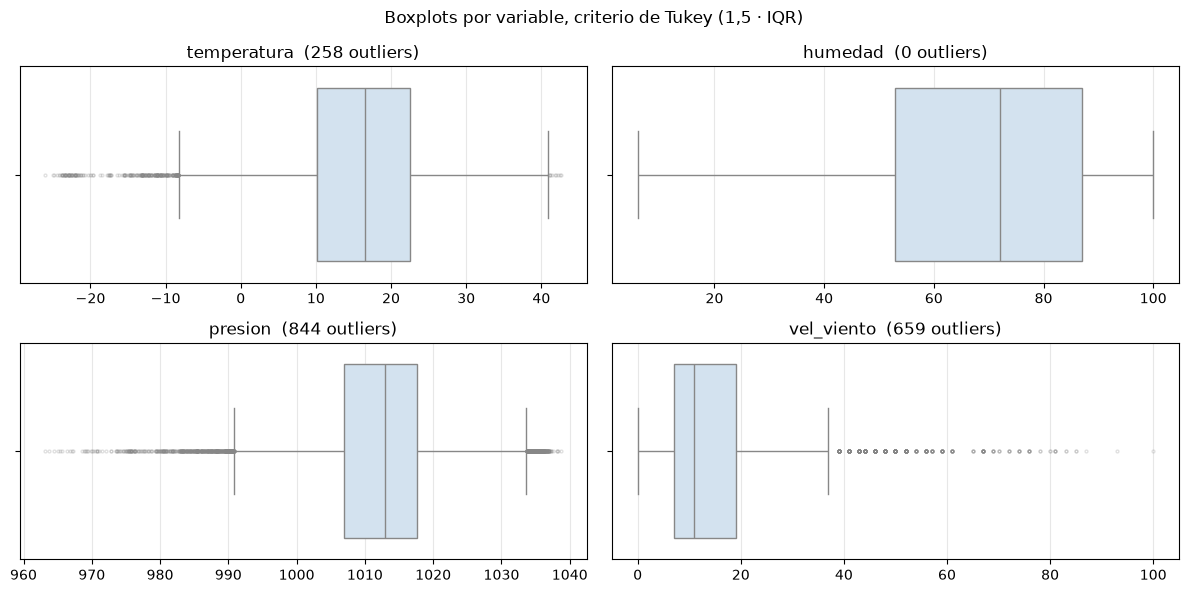

In [27]:
# Un panel por variable: las escalas no son comparables (presión ronda 1012 y
# temperatura 16), así que una caja compartida haría ilegibles a tres de las cuatro.
# whis=1.5 es el default, lo dejo explícito para que se vea que es el mismo
# criterio que usé en la tabla de 2a.
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for v, ax in zip(VARS, axes.ravel()):
    sns.boxplot(x=clima[v], ax=ax, whis=1.5, color="#cfe2f3",
                fliersize=2, flierprops={"alpha": 0.25})
    ax.set_title(f"{v}  ({out[v].sum()} outliers)")
    ax.set_xlabel("")

fig.suptitle("Boxplots por variable, criterio de Tukey (1,5 · IQR)")
fig.tight_layout()
plt.show()

Grafiqué cada variable en su propio panel porque las escalas no se parecen en nada: la
presión ronda los 1.012 hPa y la temperatura los 16 °C. En un mismo eje, la presión se
comería a las otras tres.

Los cuatro paneles muestran lo mismo que la tabla del punto anterior, pero se entiende más
rápido. La temperatura tiene una nube de puntos larga hacia la izquierda y casi nada a la
derecha. La presión tiene puntos de los dos lados, muchos más abajo que arriba. La
velocidad del viento tiene todos sus puntos de un solo lado y el bigote izquierdo cortado
en 0, que es el mínimo posible.

La humedad no tiene ningún punto marcado y sus bigotes llegan hasta 6 y 100, o sea hasta
sus valores mínimo y máximo. Acá se ve algo que conviene aclarar: el bigote no se dibuja en
el límite del criterio sino en la última observación que queda adentro. El límite de la
humedad daba 2 y 138, pero como no hay datos ahí, los bigotes se quedan en 6 y 100.

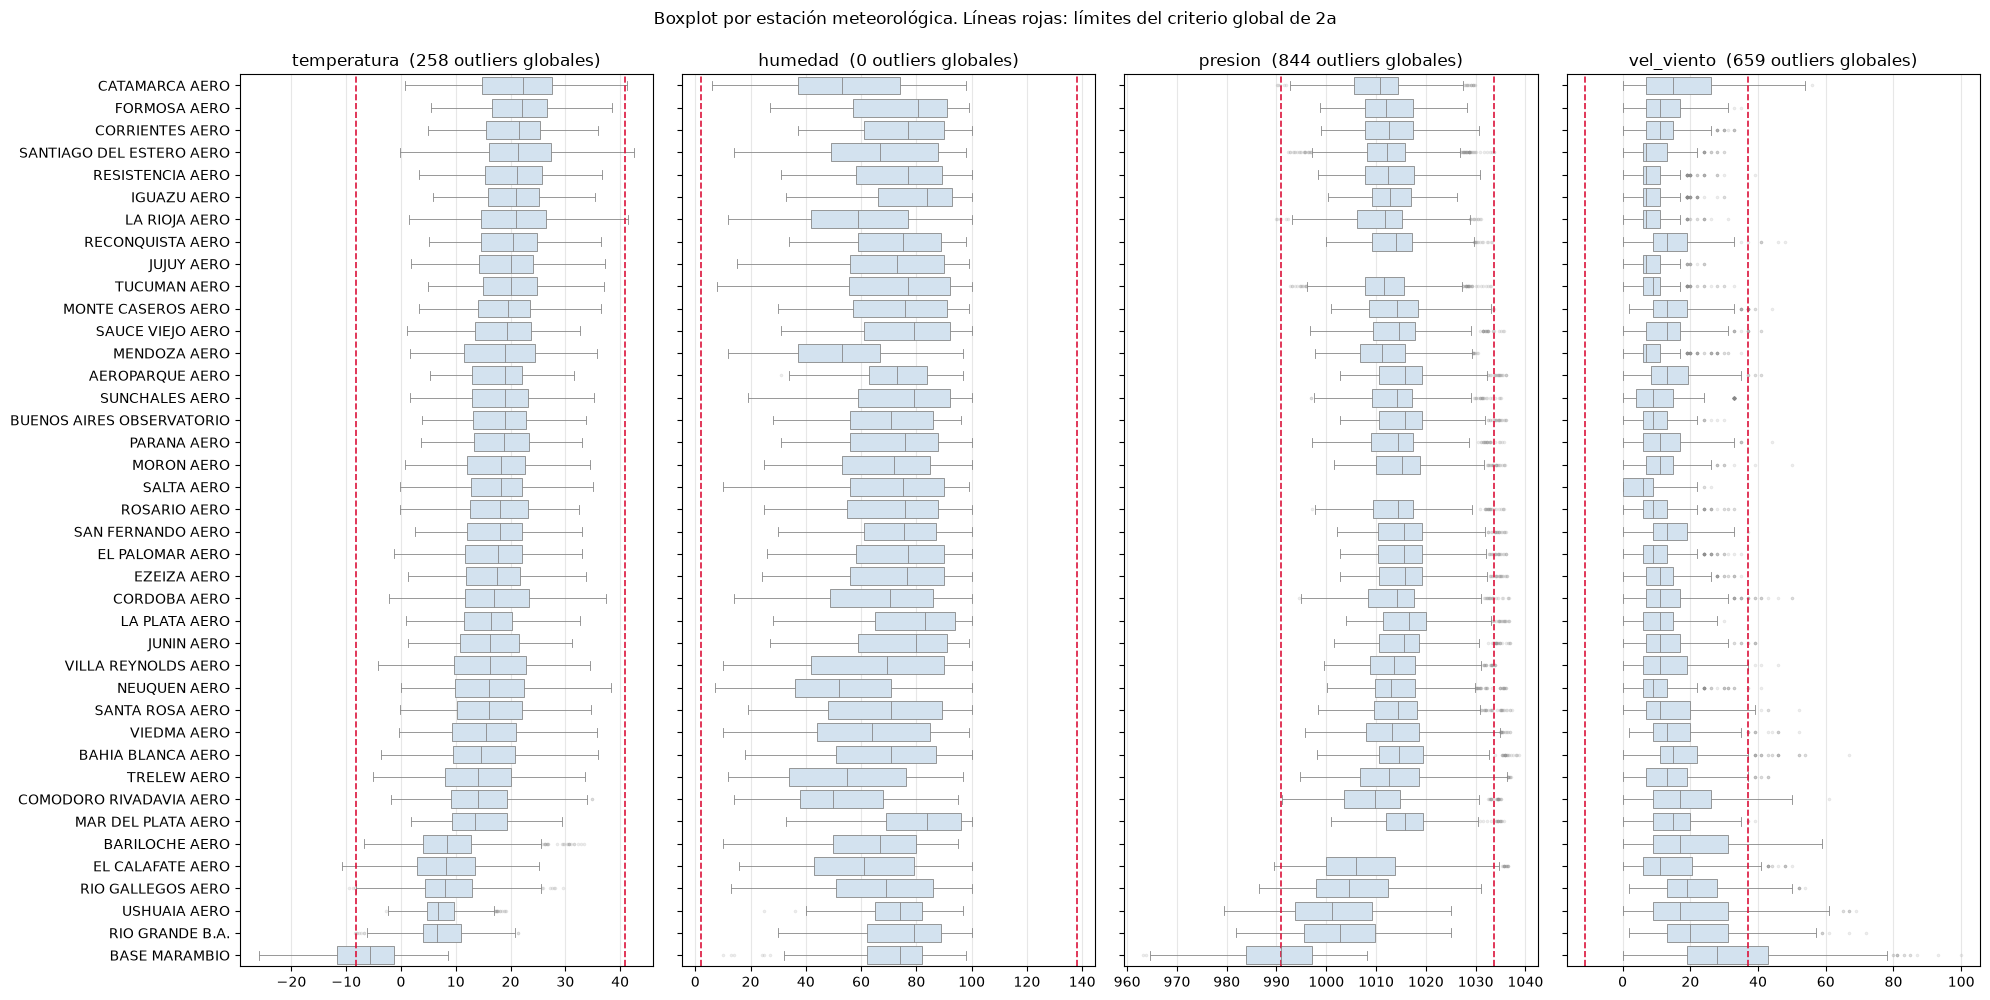

In [28]:
# Las 40 estaciones ordenadas por mediana de temperatura, de la más cálida a la más fría.
# Uso el mismo orden en los cuatro paneles para poder leer cada fila como una estación.
orden = (clima.groupby("estacion_meteorologica").temperatura
              .median().sort_values(ascending=False).index)

fig, axes = plt.subplots(1, 4, figsize=(20, 10), sharey=True)

for v, ax in zip(VARS, axes):
    sns.boxplot(data=clima, x=v, y="estacion_meteorologica", order=orden, ax=ax,
                whis=1.5, color="#cfe2f3", fliersize=1.5,
                flierprops={"alpha": 0.2}, linewidth=0.6)
    # los bigotes del criterio global calculado en 2a, para ver quién cae afuera
    ax.axvline(lim[v][0], color="crimson", ls="--", lw=1.2)
    ax.axvline(lim[v][1], color="crimson", ls="--", lw=1.2)
    ax.set_title(f"{v}  ({out[v].sum()} outliers globales)")
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Boxplot por estación meteorológica. "
             "Líneas rojas: límites del criterio global de 2a", y=0.995)
fig.tight_layout()
plt.show()

In [29]:
# Cuántos outliers globales aporta cada estación, por variable.
tabla_est = out.assign(estacion=clima.estacion_meteorologica).groupby("estacion").sum()
tabla_est["total"] = tabla_est.sum(axis=1)

print(f"estaciones sin ningún outlier: {(tabla_est.total == 0).sum()} de {len(tabla_est)}")
tabla_est.sort_values("total", ascending=False).head(10)

estaciones sin ningún outlier: 7 de 40


,temperatura,humedad,presion,vel_viento,total
estacion,,,,,
BASE MARAMBIO,230,0,283,171,684
USHUAIA AERO,0,0,99,99,198
RIO GRANDE B.A.,1,0,72,80,153
RIO GALLEGOS AERO,5,0,49,45,99
EL CALAFATE AERO,13,0,40,32,85
BARILOCHE AERO,0,0,0,75,75
BAHIA BLANCA AERO,0,0,24,25,49
CATAMARCA AERO,1,0,3,38,42
COMODORO RIVADAVIA AERO,0,0,15,27,42


El gráfico global dice cuántos outliers hay, pero no dónde están. Por eso rehice los
boxplots separando por estación meteorológica, ordenadas por temperatura mediana, de la más
cálida arriba a la más fría abajo. Las líneas rojas son los límites del criterio global.

La última fila contesta casi todo. La caja entera de Base Marambio queda a la izquierda de
la línea roja en temperatura, y también en presión. No son observaciones raras: es una
estación entera que quedó del lado de afuera de un límite calculado con las 40 mezcladas.
Las que siguen hacia arriba, Río Grande, Ushuaia, Río Gallegos y El Calafate, cruzan la
línea con parte de sus datos. De ahí salen los outliers bajos de temperatura y buena parte
de los de presión.

Lo contrario también pasa. Casi todas las estaciones tienen puntos marcados en velocidad
del viento aunque estén lejos de la línea roja global. Son valores altos para esa estación
pero normales para el país, así que el criterio global no los ve.

Las dos cosas juntas muestran que un outlier no es una propiedad del dato sino de con qué
lo comparo. Con el criterio global estoy midiendo cuánto se aleja cada observación del
clima promedio argentino, que no es lo mismo que buscar mediciones sospechosas. Para lo
segundo habría que calcular los límites estación por estación.

### 2c. Desvíos de la media

> Verifique a cuántos desvíos de la media se encuentran las observaciones que se identificaron como outliers.
> ¿Hay relación con los criterios de identificación utilizados en los boxplots?
> Compare estos valores con los valores (bigotes) del boxplot.

In [30]:
# z-score clásico: cuántos desvíos de la media separa a cada observación.
z = (clima[VARS] - clima[VARS].mean()) / clima[VARS].std()

filas = []
for v in VARS:
    zo = z.loc[out[v], v].abs()          # |z| de las observaciones marcadas por Tukey
    filas.append({
        "variable": v,
        "n outliers": int(out[v].sum()),
        "|z| mínimo": round(zo.min(), 2) if len(zo) else np.nan,
        "|z| promedio": round(zo.mean(), 2) if len(zo) else np.nan,
        "|z| máximo": round(zo.max(), 2) if len(zo) else np.nan,
    })

pd.DataFrame(filas).set_index("variable")

,n outliers,|z| mínimo,|z| promedio,|z| máximo
variable,,,,
temperatura,258,2.72,3.37,4.70
humedad,0,NaN,NaN,NaN
presion,844,2.28,2.76,5.23
vel_viento,659,2.55,3.41,8.65


In [31]:
# Traduzco los límites de Tukey a unidades de desvío para poder compararlos
# entre variables y contra el valor teórico.
# Bajo una distribución normal, Q1 - 1,5·IQR cae siempre a 2,698 desvíos de la media.
TEORICO = 2.698

filas = []
for v in VARS:
    m, s = clima[v].mean(), clima[v].std()
    filas.append({
        "variable": v,
        "límite inf": round(lim[v][0], 2),
        "z del límite inf": round((lim[v][0] - m) / s, 2),
        "límite sup": round(lim[v][1], 2),
        "z del límite sup": round((lim[v][1] - m) / s, 2),
        "curtosis": round(stats.kurtosis(clima[v].dropna()), 2),
    })

print(f"valor teórico bajo normalidad: ±{TEORICO}")
pd.DataFrame(filas).set_index("variable")

valor teórico bajo normalidad: ±2.698


,límite inf,z del límite inf,límite sup,z del límite sup,curtosis
variable,,,,,
temperatura,-8.25,-2.72,40.95,2.77,0.70
humedad,2.00,-3.15,138.00,3.27,-0.74
presion,990.85,-2.28,1033.65,2.27,1.52
vel_viento,-11.00,-2.45,37.00,2.35,4.89


Los outliers que marqué en 2a están entre 2,3 y 8,7 desvíos de la media, según la variable.
El dato más útil de la tabla es el mínimo, porque es el outlier menos extremo, el primero
que pasa el bigote: 2,72 en temperatura, 2,55 en velocidad del viento y 2,28 en presión.
Ninguno llega a los 3 desvíos que se suelen usar como umbral.

La segunda tabla explica por qué. Traduje los límites del boxplot a desvíos y dan distinto
en cada variable: 2,27 en presión, 2,35 en velocidad del viento, 2,77 en temperatura y 3,27
en humedad. Si la distribución fuera normal, los cuatro darían 2,698. O sea que el límite de
Tukey no está fijo en ninguna cantidad de desvíos: se mueve con la forma de cada
distribución.

El orden sigue a la curtosis, que ya había calculado antes. Humedad tiene la más baja,
-0,74, y es la que más lejos pone el límite. Presión y velocidad del viento tienen las más
altas y son las que más cerca lo ponen. Las colas pesadas agrandan el desvío, y como los
cuartiles no se mueven, el límite termina cayendo a menos desvíos de distancia.

In [32]:
# ¿Marcan lo mismo Tukey y el z-score? Cuento las coincidencias.
filas = []
for v in VARS:
    za = z[v].abs()
    for umbral in (3, TEORICO):
        filas.append({
            "variable": v,
            "umbral |z|": umbral,
            "solo Tukey": int((out[v] & ~(za > umbral)).sum()),
            "ambos": int((out[v] & (za > umbral)).sum()),
            "solo z-score": int((~out[v] & (za > umbral)).sum()),
        })

pd.DataFrame(filas).set_index(["variable", "umbral |z|"])

solo Tukey  ambos  solo z-score
variable    umbral |z|                                 
temperatura 3.000               86    172             0
            2.698                0    258            14
humedad     3.000                0      0             0
            2.698                0      0            27
presion     3.000              652    192             0
            2.698              544    300             0
vel_viento  3.000              293    366             0
            2.698              112    547             0

Los dos criterios están relacionados pero no coinciden, y la relación cambia según la
variable.

En presión y en velocidad del viento, el z-score no marca ni una observación que Tukey no
haya marcado antes. Con umbral 3, Tukey encuentra 844 en presión y el z-score solo 192 de
esas. Es decir que acá Tukey contiene al z-score y además agrega 652 más. Pasa lo mismo en
velocidad del viento, con 659 contra 366.

En humedad es al revés. Tukey no marca nada, con umbral 3 el z-score tampoco, y recién
bajando a 2,698 aparecen 27 observaciones. Esto no contradice lo que dije en 2a, lo precisa:
humedad no tiene outliers por el criterio de cuartiles, pero sí tiene valores que están
lejos de la media en unidades de desvío. Son dos preguntas distintas.

La comparación con los bigotes cierra la idea. El bigote está en el mismo lugar en los dos
casos, lo que cambia es la vara con que se lo mide. Tukey lo pone a 1,5 IQR de los
cuartiles, siempre. El z-score lo pondría a 3 desvíos de la media, siempre. Que uno sea más
exigente que el otro depende de cuánto mide el IQR de esa variable comparado con su desvío.

In [33]:
# Enmascaramiento: los outliers forman parte del cálculo del desvío que después
# se usa para juzgarlos. Comparo el desvío con y sin ellos.
filas = []
for v in VARS:
    s_con = clima[v].std()
    s_sin = clima.loc[~out[v], v].std()
    filas.append({
        "variable": v,
        "desvío con outliers": round(s_con, 2),
        "desvío sin outliers": round(s_sin, 2),
        "% de inflación": round(100 * (s_con / s_sin - 1), 1),
    })

pd.DataFrame(filas).set_index("variable")

,desvío con outliers,desvío sin outliers,% de inflación
variable,,,
temperatura,8.96,8.39,6.8
humedad,21.19,21.19,0.0
presion,9.39,7.92,18.5
vel_viento,10.00,8.06,24.1


Queda un problema con el z-score que el boxplot no tiene. La media y el desvío se calculan
con todos los datos, incluidos los outliers, así que los valores extremos ayudan a definir
la vara con la que después se los mide. Sacando los outliers, el desvío de velocidad del
viento baja de 10,00 a 8,06, un 24,1 % menos. En presión baja 18,5 % y en temperatura 6,8 %.

Con el desvío sin inflar, esos mismos outliers quedarían a más desvíos de los que muestra la
primera tabla. Y si repitiera el procedimiento aparecerían outliers nuevos, porque el desvío
sigue bajando. El criterio de cuartiles no tiene este problema: los outliers no mueven el
Q1 ni el Q3.

### 2d. Filas con outliers en más de una variable

> Analice si existen filas con outliers en más de una variable. Agregue una columna
> "CANT_OUT" al dataset que contabilice la cantidad de variables observadas como *outliers*
> en el dataset y realice al menos dos gráficos para ver dónde se ubican esos valores.
> ¿Qué puede comentar al respecto?

In [34]:
# CANT_OUT: en cuántas variables esta fila quedó marcada como outlier.
# CANT_OBS: sobre cuántas variables se pudo contar, porque un nulo no es un outlier
# pero tampoco es un dato observado. Con 1.726 filas sin presión, la diferencia importa.
clima["CANT_OUT"] = out.sum(axis=1)
clima["CANT_OBS"] = clima[VARS].notna().sum(axis=1)

print("Distribución de CANT_OUT")
print(clima.CANT_OUT.value_counts().sort_index())
print(f"\nfilas con al menos un outlier : {(clima.CANT_OUT > 0).sum()}")
print(f"filas con más de una variable : {(clima.CANT_OUT > 1).sum()}")
print(f"filas con menos de 4 variables observadas: {(clima.CANT_OBS < 4).sum()}")

Distribución de CANT_OUT
CANT_OUT
0    21582
1     1167
2      216
3       54
Name: count, dtype: int64

filas con al menos un outlier : 1437
filas con más de una variable : 270
filas con menos de 4 variables observadas: 1733


Sí existen filas con outliers en más de una variable. De las 1.437 filas que tienen al menos
uno, 270 tienen dos variables marcadas y 54 tienen tres. Es el 19 % de las filas con
outliers, sobre un dataset donde solo el 6,2 % de las filas tiene alguno.

Los pares no son cualquiera. Presión y viento coinciden en 173 filas, temperatura y presión
en 116, temperatura y viento en 89. Humedad no coincide con nada porque no tiene ningún
outlier. La última tabla muestra que esas coincidencias no son producto del azar: se dan
entre 7 y 12 veces más de lo que se esperaría si las variables fueran independientes.

Agregué también CANT_OBS, que cuenta sobre cuántas variables se pudo evaluar cada fila. Hay
1.733 filas con menos de cuatro, casi todas por los faltantes de presión. Sin esa columna,
una fila sin presión y una fila con presión normal parecerían lo mismo.

In [35]:
# Segundo criterio: los mismos cuartiles pero calculados dentro de cada estación,
# así cada observación se compara contra su propio clima y no contra el del país.
out_est = pd.DataFrame(index=clima.index)

for v in VARS:
    g = clima.groupby("estacion_meteorologica")[v]
    q1 = g.transform(lambda s: s.quantile(0.25))
    q3 = g.transform(lambda s: s.quantile(0.75))
    iqr = q3 - q1
    out_est[v] = (clima[v] < q1 - 1.5 * iqr) | (clima[v] > q3 + 1.5 * iqr)

clima["CANT_OUT_EST"] = out_est.sum(axis=1)

print("outliers por variable")
print(pd.DataFrame({"global": out.sum(), "por estación": out_est.sum()}))
print("\ndistribución de CANT_OUT_EST")
print(clima.CANT_OUT_EST.value_counts().sort_index())
print(f"\nfilas con más de una variable: global {(clima.CANT_OUT > 1).sum()}, "
      f"por estación {(clima.CANT_OUT_EST > 1).sum()}")

outliers por variable
             global  por estación
temperatura     258            60
humedad           0             9
presion         844           658
vel_viento      659           581

distribución de CANT_OUT_EST
CANT_OUT_EST
0    21725
1     1280
2       14
Name: count, dtype: int64

filas con más de una variable: global 270, por estación 14


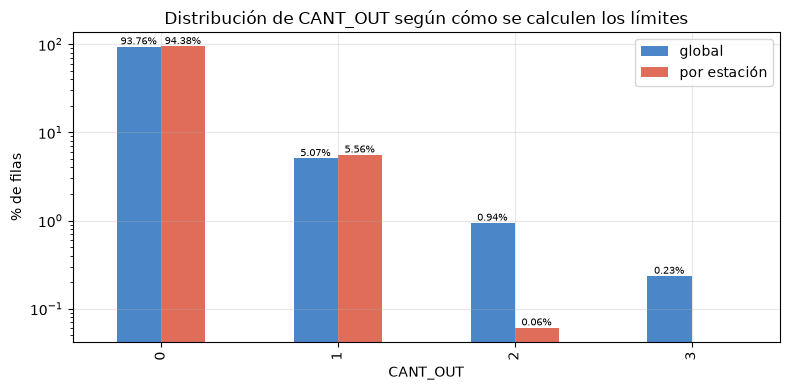

In [36]:
# Escala logarítmica porque el 0 se lleva el 94 % y sin log los demás no se ven.
comp = pd.DataFrame({
    "global": clima.CANT_OUT.value_counts(normalize=True).sort_index() * 100,
    "por estación": clima.CANT_OUT_EST.value_counts(normalize=True).sort_index() * 100,
}).fillna(0)

ax = comp.plot(kind="bar", figsize=(8, 4), color=["#4a86c8", "#e06c5a"])
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f%%", fontsize=7)
ax.set_yscale("log")
ax.set_xlabel("CANT_OUT")
ax.set_ylabel("% de filas")
ax.set_title("Distribución de CANT_OUT según cómo se calculen los límites")
plt.tight_layout()
plt.show()

Como los límites globales se calculan mezclando 40 climas, agregué un segundo criterio con
los mismos cuartiles pero calculados dentro de cada estación. Cada observación se compara
contra su propio clima.

Cambia bastante. La temperatura pierde el 77 % de sus outliers, de 258 a 60. La presión
pierde el 22 % y el viento el 12 %. La humedad hace lo contrario: pasa de 0 a 9. Eso
completa lo que venía diciendo en 2a y 2c: la humedad sí tiene valores raros, pero solo se
ven cuando se la compara con su estación, no con el país.

El derrumbe más fuerte está en las coincidencias. Las 270 filas con más de una variable
quedan en 14, y las 54 con tres variables desaparecen por completo. Las coincidencias no
eran de filas raras, eran de estaciones raras: en Marambio la temperatura y la presión están
bajas casi todo el año, así que muchas de sus filas cruzaban dos límites a la vez sin que
ese día pasara nada en particular.

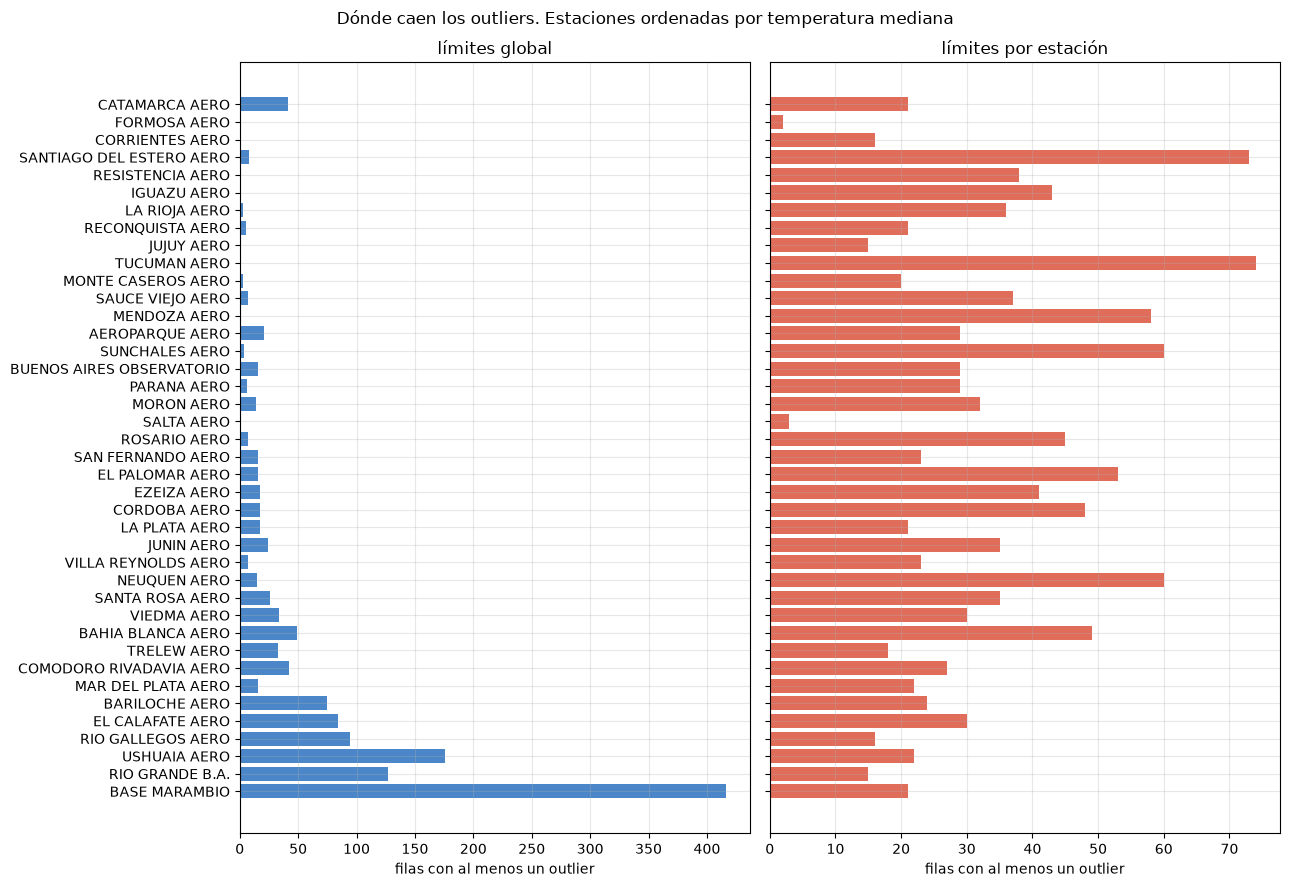

In [37]:
# Mismo orden de estaciones que el boxplot de 2b, de la más cálida arriba a la más fría
# abajo, para poder comparar los dos gráficos sin tener que buscar cada nombre.
por_est = pd.DataFrame({
    "global": clima[clima.CANT_OUT > 0].estacion_meteorologica.value_counts(),
    "por estación": clima[clima.CANT_OUT_EST > 0].estacion_meteorologica.value_counts(),
}).reindex(orden).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 9), sharey=True)

for (col, color), ax in zip([("global", "#4a86c8"), ("por estación", "#e06c5a")], axes):
    ax.barh(por_est.index[::-1], por_est[col][::-1], color=color)
    ax.set_title(f"límites {col}")
    ax.set_xlabel("filas con al menos un outlier")

fig.suptitle("Dónde caen los outliers. Estaciones ordenadas por temperatura mediana")
plt.tight_layout()
plt.show()

Los dos paneles son el mismo cálculo con distinta referencia y dan resultados casi opuestos.

Con límites globales hay un degradé claro de sur a norte. Marambio aporta 414 filas, y
después siguen Río Grande, Ushuaia, Río Gallegos y El Calafate. Las estaciones del norte
casi no aparecen. Ese panel no está mostrando dónde hay observaciones anómalas, está
mostrando qué estaciones tienen un clima distinto del promedio argentino.

Con límites por estación el gráfico se aplana y hasta se da vuelta. Los primeros son Tucumán
con 74 y Santiago del Estero con 73, y Marambio queda en el montón. Acá ser extremo es otra
cosa: no es tener un clima duro, es tener días que se salen de lo habitual en ese lugar.

In [38]:
# Cuántas filas comparten outlier entre cada par de variables.
display(out.astype(int).T @ out.astype(int))

# Un par puede coincidir simplemente porque las dos variables tienen muchos outliers.
# Comparo lo observado contra lo que se esperaría si las dos fueran independientes.
import itertools

filas = []
for a, b in itertools.combinations(VARS, 2):
    val = clima[[a, b]].notna().all(axis=1)      # filas con las dos variables observadas
    n = val.sum()
    obs = (out[a] & out[b]).sum()
    esp = out.loc[val, a].sum() * out.loc[val, b].sum() / n
    filas.append({
        "par": f"{a} + {b}",
        "observadas": int(obs),
        "esperadas si fueran independientes": round(esp, 1),
        "veces más": round(obs / esp, 1) if esp else None,
    })

pd.DataFrame(filas).set_index("par")


,temperatura,humedad,presion,vel_viento
temperatura,258,0,116,89
humedad,0,0,0,0
presion,116,0,844,173
vel_viento,89,0,173,659


,observadas,esperadas si fueran independientes,veces más
par,,,
temperatura + humedad,0,0.0,NaN
temperatura + presion,116,10.2,11.3
temperatura + vel_viento,89,7.4,12.0
humedad + presion,0,0.0,NaN
humedad + vel_viento,0,0.0,NaN
presion + vel_viento,173,23.2,7.5


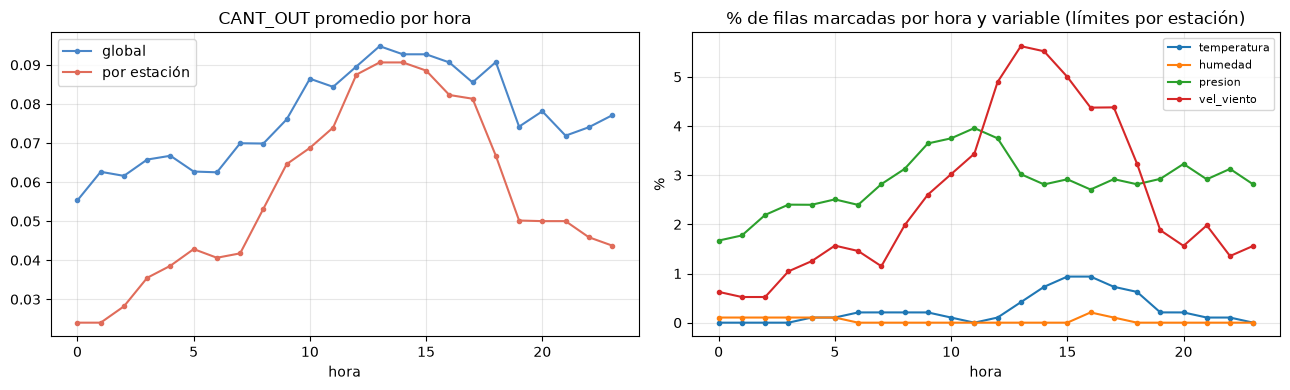

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(clima.CANT_OUT.groupby(clima.hora).mean(), marker="o", ms=3,
             label="global", color="#4a86c8")
axes[0].plot(clima.CANT_OUT_EST.groupby(clima.hora).mean(), marker="o", ms=3,
             label="por estación", color="#e06c5a")
axes[0].set_title("CANT_OUT promedio por hora")
axes[0].set_xlabel("hora")
axes[0].legend()

# Abro por variable para ver si el ciclo diario es el mismo en todas
for v in VARS:
    axes[1].plot(out_est[v].groupby(clima.hora).mean() * 100, marker="o", ms=3, label=v)
axes[1].set_title("% de filas marcadas por hora y variable (límites por estación)")
axes[1].set_xlabel("hora")
axes[1].set_ylabel("%")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

El segundo "dónde" es dentro del día. Los dos criterios tienen el mismo pico, a las 13 y 14,
y el mínimo de madrugada. Con límites por estación la diferencia es más marcada: 0,024 de
promedio a las 3 de la mañana contra 0,091 a las 13, casi cuatro veces más.

Abriendo por variable se ve que no todas siguen el mismo ciclo. El viento marca el 5,7 % de
sus filas a las 13 y baja a menos del 1 % de madrugada, que es el ciclo típico del viento
diurno: con el sol la atmósfera se mezcla y las ráfagas aumentan. La presión tiene su propia
forma, más alta a la mañana, que no coincide con la del viento, así que responden a cosas
distintas.

Esto es lo más importante del gráfico: si los outliers se concentran a una hora determinada
y siguen un patrón regular, no son errores de medición. Son el ciclo diario visto desde el
criterio de outliers.

Lo que puedo comentar sobre CANT_OUT es que mide dos cosas distintas según cómo se calculen
los límites, y conviene no confundirlas.

Con límites globales mide cuánto se aleja cada fila del clima promedio del país. Sirve para
encontrar estaciones atípicas, y de hecho las encuentra, pero sus filas con dos y tres
variables marcadas no son días excepcionales: son días normales en lugares extremos.

Con límites por estación mide cuánto se aleja cada fila de lo habitual en su lugar. Ahí
quedan 14 filas con dos variables marcadas, y esas sí son candidatas a mirar una por una,
sea porque hubo un evento meteorológico o porque falló un instrumento.

In [40]:
# Las filas que quedan marcadas en dos variables cuando los límites se calculan
# dentro de cada estación. Son pocas, así que se pueden mirar una por una.
m = clima.CANT_OUT_EST > 1

detalle = clima.loc[m, ["fecha", "hora", "estacion_meteorologica"] + VARS].copy()
detalle["fecha"] = detalle.fecha.dt.date
# qué variables se marcaron en cada fila
detalle["marcadas"] = out_est.loc[m].apply(lambda r: " + ".join(r.index[r]), axis=1)

detalle.sort_values(["fecha", "hora"]).reset_index(drop=True)

,fecha,hora,estacion_meteorologica,temperatura,humedad,presion,vel_viento,marcadas
0,2025-11-20,13,SANTIAGO DEL ESTERO AERO,37.8,24.0,996.9,30.0,presion + vel_viento
1,2025-11-20,14,SANTIAGO DEL ESTERO AERO,39.4,22.0,995.8,24.0,presion + vel_viento
2,2025-11-20,17,LA RIOJA AERO,41.4,17.0,990.0,19.0,presion + vel_viento
3,2025-11-20,17,SANTIAGO DEL ESTERO AERO,41.2,18.0,992.8,26.0,presion + vel_viento
4,2025-11-20,17,TUCUMAN AERO,36.4,29.0,992.7,19.0,presion + vel_viento
5,2025-11-20,18,SANTIAGO DEL ESTERO AERO,41.0,18.0,992.3,30.0,presion + vel_viento
6,2026-01-20,16,USHUAIA AERO,17.4,36.0,996.8,33.0,temperatura + humedad
7,2026-05-10,2,TUCUMAN AERO,6.8,86.0,1028.5,19.0,presion + vel_viento
8,2026-05-10,3,TUCUMAN AERO,6.6,84.0,1027.5,19.0,presion + vel_viento
9,2026-08-10,15,NEUQUEN AERO,5.0,66.0,1031.8,26.0,presion + vel_viento


Mirando esas 14 filas una por una, no son 14 casos sueltos: son cuatro episodios. Seis filas
son de la tarde del 20 de noviembre de 2025, repartidas entre Santiago del Estero, La Rioja
y Tucumán, con temperaturas de 36 a 41 °C, presión baja para esas estaciones y viento. Cinco
son del 10 de agosto de 2026 en Neuquén, entre las 15 y las 23. Dos son de la madrugada del
10 de mayo en Tucumán y una sola es de Ushuaia.

En todos los casos las horas son consecutivas dentro de la misma estación, y en el episodio
de noviembre hay tres estaciones vecinas marcadas a la misma hora. Eso descarta la falla de
instrumento, que fue el diagnóstico del valor anómalo del ejercicio 1: ahí el pico era
aislado, duraba una hora y el resto de los sensores no se movía. Acá pasa lo contrario, así
que lo que marca CANT_OUT con límites por estación son episodios meteorológicos reales.

## Ejercicio 3 — Discretización

### 3a. Cinco rangos según el análisis de frecuencia

> Transforme el atributo a discreto, definiendo 5 rangos de acuerdo al análisis
> de frecuencia de los valores encontrados para el atributo. ¿Qué tipo de
> variable se obtiene?

observaciones: 23014  |  nulos: 5
valores distintos: 95  |  rango observado: 6 a 100
frecuencia por valor: mín 1, máx 530 (en humedad = 95), media 242


,n,%,% acum
humedad,,,
"[0, 10)",7,0.0,0.0
"[10, 20)",248,1.1,1.1
"[20, 30)",783,3.4,4.5
"[30, 40)",1498,6.5,11.0
"[40, 50)",2393,10.4,21.4
"[50, 60)",2720,11.8,33.2
"[60, 70)",3091,13.4,46.6
"[70, 80)",3483,15.1,61.7
"[80, 90)",4081,17.7,79.4


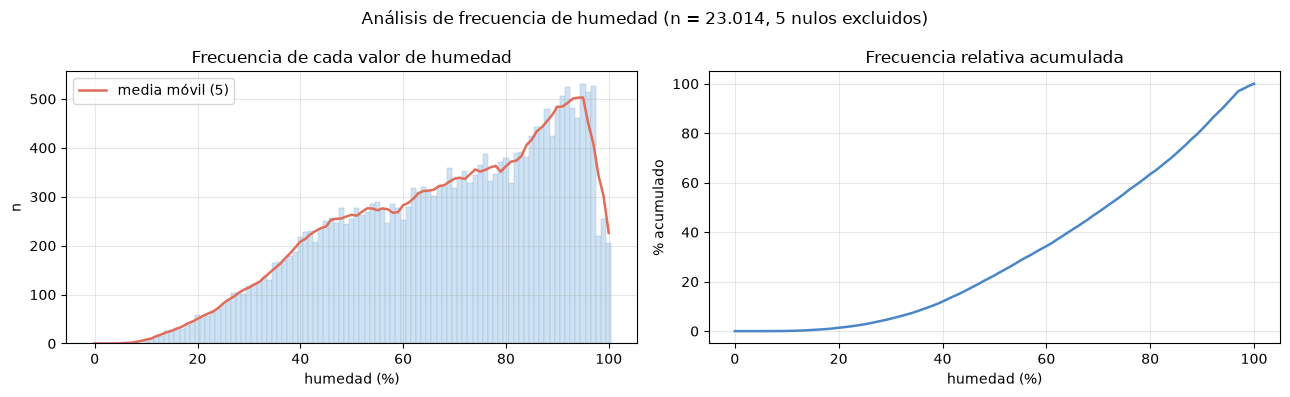

In [41]:
# Análisis de frecuencia de los valores observados. humedad toma 95 valores
# enteros distintos, así que puedo contar la frecuencia de cada valor uno por
# uno sin agrupar nada: ese conteo es el insumo para decidir dónde cortar.
h = clima["humedad"]
frec = h.value_counts().reindex(range(0, 101), fill_value=0).sort_index()

print(f"observaciones: {h.notna().sum()}  |  nulos: {h.isna().sum()}")
print(f"valores distintos: {h.nunique()}  |  rango observado: {h.min():g} a {h.max():g}")
print(f"frecuencia por valor: mín {frec[frec > 0].min()}, "
      f"máx {frec.max()} (en humedad = {frec.idxmax()}), media {frec[frec > 0].mean():.0f}")

# Frecuencia de 10 en 10 para leer la forma gruesa antes del detalle. El último
# tramo va hasta 101 porque el 100 es un valor posible (saturación) y con cierre
# a izquierda un [90, 100) lo dejaría afuera.
BORDES_10 = list(range(0, 100, 10)) + [101]
por_decena = pd.DataFrame({
    "n": h.groupby(pd.cut(h, bins=BORDES_10, right=False), observed=False).size()
})
por_decena["%"] = (100 * por_decena.n / por_decena.n.sum()).round(1)
por_decena["% acum"] = por_decena["%"].cumsum().round(1)
display(por_decena)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel izquierdo: la frecuencia de cada valor entero. Encima, una media móvil
# de 5 para ver la tendencia sin el ruido de valor a valor, que es lo que
# necesito para ubicar los cortes.
axes[0].bar(frec.index, frec.values, width=1.0, color="#cfe2f3",
            edgecolor="#9ab8d4", lw=0.3)
axes[0].plot(frec.index, frec.rolling(5, center=True, min_periods=1).mean(),
             color="#e06c5a", lw=1.8, label="media móvil (5)")
axes[0].set_title("Frecuencia de cada valor de humedad")
axes[0].set_xlabel("humedad (%)")
axes[0].set_ylabel("n")
axes[0].legend()

# Panel derecho: la acumulada. Acá lo que importa es la pendiente, porque un
# tramo de pendiente constante es un tramo donde la frecuencia no cambia.
acum = 100 * frec.cumsum() / frec.sum()
axes[1].plot(acum.index, acum.values, color="#4a86c8", lw=1.8)
axes[1].set_title("Frecuencia relativa acumulada")
axes[1].set_xlabel("humedad (%)")
axes[1].set_ylabel("% acumulado")
axes[1].set_yticks(range(0, 101, 20))

fig.suptitle("Análisis de frecuencia de humedad (n = 23.014, 5 nulos excluidos)")
fig.tight_layout()
plt.show()

In [42]:
# La curva de frecuencias no tiene valles: crece de punta a punta hasta el pico
# y después cae. Así que no puedo cortar "en los mínimos locales", tengo que
# cortar donde cambia la pendiente. Esta tabla mide esa pendiente sobre la media
# móvil, para que los quiebres que elijo estén respaldados por un número y no
# por lo que me parece que veo en el gráfico.
suave = frec.rolling(5, center=True, min_periods=1).mean()
QUIEBRES = [6, 12, 45, 60, 85, 95, 100]

pend = pd.DataFrame([{
    "tramo": f"{a} a {b}",
    "frec. inicial": round(suave.loc[a]),
    "frec. final": round(suave.loc[b]),
    "pendiente": round((suave.loc[b] - suave.loc[a]) / (b - a), 2),
} for a, b in zip(QUIEBRES[:-1], QUIEBRES[1:])]).set_index("tramo")

print(f"pico de la curva suavizada en humedad = {suave.idxmax()}  ({suave.max():.0f} casos)")
display(pend)

# La curva muestra 6 tramos y los rangos pedidos son 5, así que una fusión es
# obligatoria. Fusiono el arranque (6 a 12) con la subida fuerte: son 27
# observaciones, el 0,12 % del total, y un rango con 27 casos queda vacío en
# cualquier cruce posterior. Los otros cinco tramos quedan como están.
print(f"\nobservaciones por debajo de 12: {int(frec.loc[:11].sum())} "
      f"({100 * frec.loc[:11].sum() / frec.sum():.2f} % del total)")

pico de la curva suavizada en humedad = 95  (503 casos)


,frec. inicial,frec. final,pendiente
tramo,,,
6 a 12,1,15,2.30
12 a 45,15,239,6.79
45 a 60,239,283,2.91
60 a 85,283,416,5.34
85 a 95,416,503,8.66
95 a 100,503,226,-55.40



observaciones por debajo de 12: 27 (0.12 % del total)


In [43]:
# Los cortes salen de leer la curva de arriba: separo los tramos donde la
# frecuencia se comporta distinto. La regla que sigo es cortar donde cambia la
# pendiente de la media móvil, no donde los bins quedan parejos.
# Primer borde 0 y último 101, no el mínimo y el máximo observados: el dominio
# de la humedad relativa es 0 a 100 por definición, así que el discretizador
# queda definido sobre toda la escala y no solo sobre mi muestra.
# El 101 es para que el 100 entre en el último rango, porque los intervalos son
# cerrados a izquierda y abiertos a derecha, igual que la notación del 3c.
CORTES = [0, 45, 60, 85, 96, 101]

clima["hum_frec"] = pd.cut(clima["humedad"], bins=CORTES, right=False)

tabla = pd.DataFrame({"n": clima.hum_frec.value_counts().sort_index()})
tabla["%"] = (100 * tabla.n / tabla.n.sum()).round(1)
tabla["ancho"] = [b - a for a, b in zip(CORTES[:-1], CORTES[1:])]
tabla["mín obs"] = clima.groupby("hum_frec", observed=False).humedad.min()
tabla["máx obs"] = clima.groupby("hum_frec", observed=False).humedad.max()
display(tabla)

print(f"\nsuma de frecuencias: {tabla.n.sum()}  |  "
      f"nulos sin clasificar: {clima.hum_frec.isna().sum()}")
print(f"dtype: {clima.hum_frec.dtype.name}  |  ordenada: {clima.hum_frec.cat.ordered}")
print(f"desbalance: el rango más poblado tiene "
      f"{tabla.n.max() / tabla.n.min():.1f} veces las observaciones del menos poblado")

,n,%,ancho,mín obs,máx obs
hum_frec,,,,,
"[0, 45)",3654,15.9,45,6.0,44.0
"[45, 60)",3995,17.4,15,45.0,59.0
"[60, 85)",8443,36.7,25,60.0,84.0
"[85, 96)",5202,22.6,11,85.0,95.0
"[96, 101)",1720,7.5,5,96.0,100.0



suma de frecuencias: 23014  |  nulos sin clasificar: 5
dtype: category  |  ordenada: True
desbalance: el rango más poblado tiene 4.9 veces las observaciones del menos poblado


El análisis de frecuencia muestra una curva sin valles. La frecuencia de cada valor
crece desde 6 hasta el pico en 95, con 503 casos, y ahí cae a 226 en 100. La
acumulada tampoco tiene saltos. Eso descarta cortar en los mínimos locales, porque
no hay mínimos locales. El criterio que uso es cortar donde cambia la pendiente de
la media móvil.

La tabla de pendientes da seis tramos: un arranque lento de 6 a 12 (+2,3), una
subida fuerte hasta 45 (+6,8), una meseta hasta 60 (+2,9), una subida moderada
hasta 85 (+5,3), una subida acelerada hasta el pico en 95 (+8,7) y la caída final
(−55,4).

Son seis tramos y los rangos pedidos son cinco, así que tuve que fusionar dos.
Fusioné el arranque con la subida fuerte. Por debajo de 12 hay 27 observaciones,
el 0,12 % del total, y un rango con 27 casos queda vacío en cualquier cruce
posterior. La alternativa era juntar las dos subidas de arriba en un rango de
13.645 observaciones, el 59 % del dataset, y me parece peor.

Los cortes quedan entonces en 45, 60, 85 y 96. El 96 y no el 95 porque el 95 es el
pico, o sea el último valor del tramo que sube, y tiene que quedar del lado del
tramo que sube. Los bordes externos son 0 y 101 y no el mínimo y el máximo
observados: la humedad relativa está definida entre 0 y 100, así que prefiero que
la discretización cubra toda la escala y no solo el rango de mi muestra.

Los cinco rangos quedan de ancho desigual (45, 15, 25, 11 y 5 puntos) y con
frecuencias de 15,9 %, 17,4 %, 36,7 %, 22,6 % y 7,5 %. El más poblado tiene 4,9
veces las observaciones del menos poblado. Los 5 nulos quedan sin clasificar, no
los imputo, igual que en el ejercicio 2.

Aclaro que estos cuatro cortes son una convención mía. La acumulada es lisa, así
que el dato no fuerza ningún corte en particular. Lo que sale del dato es la regla,
y es eso lo que puedo defender.

**Qué tipo de variable se obtiene**

Una cualitativa ordinal. Las cinco categorías tienen un orden claro, [0, 45) es
menos que [45, 60), pero las distancias entre ellas no son comparables porque los
anchos son distintos. No puedo promediar, ni restar, ni decir que el salto del
primer rango al segundo equivale al del cuarto al quinto. En pandas queda como
`dtype: category` con `ordered: True`, que es lo que imprime la celda.

Lo que pierdo es la aritmética. Lo que gano es robustez: un error de medición que
mueva un registro de 88 a 91 ya no cambia nada, porque los dos caen en el mismo
rango.

### 3b. Cinco rangos por intervalos de clases

> Transforme el atributo a discreto, definiendo 5 rangos utilizando intervalos
> de clases.

In [44]:
# Intervalos de clases: cinco clases de igual ancho sobre el dominio de la
# variable. Uso el mismo dominio que en 3a, 0 a 100, así que el ancho sale de
# una división y no de una decisión mía: (100 - 0) / 5 = 20.
# El último borde es 101 por el mismo motivo que en 3a, para que el 100 entre.
K = 5
CORTES_ANCHO = list(range(0, 100, 100 // K)) + [101]

clima["hum_ancho"] = pd.cut(clima["humedad"], bins=CORTES_ANCHO, right=False)

tabla_ancho = pd.DataFrame({"n": clima.hum_ancho.value_counts().sort_index()})
tabla_ancho["%"] = (100 * tabla_ancho.n / tabla_ancho.n.sum()).round(1)
tabla_ancho["valores enteros"] = [b - a for a, b in zip(CORTES_ANCHO[:-1], CORTES_ANCHO[1:])]
tabla_ancho["mín obs"] = clima.groupby("hum_ancho", observed=False).humedad.min()
tabla_ancho["máx obs"] = clima.groupby("hum_ancho", observed=False).humedad.max()
display(tabla_ancho)

print(f"\nsuma de frecuencias: {tabla_ancho.n.sum()}  |  "
      f"nulos sin clasificar: {clima.hum_ancho.isna().sum()}")
print(f"desbalance: {tabla_ancho.n.max() / tabla_ancho.n.min():.1f}x "
      f"(en 3a fue 4,9x)")

# Por qué no dejo que pandas elija los bordes: con pd.cut(serie, 5) el ancho se
# calcula sobre el rango observado (6 a 100) y no sobre el dominio, así que da
# clases de 18,8 y bordes que no se leen.
auto = pd.cut(clima["humedad"], bins=K)
print("\nbordes automáticos de pd.cut(humedad, 5), sobre el rango observado:")
print("  " + " | ".join(str(i) for i in auto.cat.categories))

,n,%,valores enteros,mín obs,máx obs
hum_ancho,,,,,
"[0, 20)",255,1.1,20,6.0,19.0
"[20, 40)",2281,9.9,20,20.0,39.0
"[40, 60)",5113,22.2,20,40.0,59.0
"[60, 80)",6574,28.6,20,60.0,79.0
"[80, 101)",8791,38.2,21,80.0,100.0



suma de frecuencias: 23014  |  nulos sin clasificar: 5
desbalance: 34.5x (en 3a fue 4,9x)

bordes automáticos de pd.cut(humedad, 5), sobre el rango observado:
  (5.906, 24.8] | (24.8, 43.6] | (43.6, 62.4] | (62.4, 81.2] | (81.2, 100.0]


Acá no hay nada que elegir. Fijado el dominio en 0 a 100 y la cantidad de rangos en
5, el ancho es 20 y los cortes son 20, 40, 60 y 80. Toda la decisión está un paso
antes, en el dominio.

Las cinco frecuencias crecen de punta a punta: 1,1 %, 9,9 %, 22,2 %, 28,6 % y
38,2 %. El rango más poblado tiene 34,5 veces las observaciones del menos poblado,
contra 4,9 veces en el 3a y con la misma cantidad de rangos. La diferencia es que en
el 3a moví los bordes para seguir la densidad, y acá los bordes son ciegos a la
densidad.

El primer rango se queda con 255 casos. No es un defecto del cálculo, es la
variable: la humedad tiene asimetría negativa (−0,48, calculada en el ejercicio 2) y
en el dataset hay muy pocos registros de humedad baja. Los bordes de igual ancho
hacen que esa asimetría se lea directo en la tabla de frecuencias, que es para lo
que sirve una tabla de clases.

Lo que se pierde es resolución arriba. `[80, 101)` junta 8.791 observaciones, el
38,2 %, y adentro quedan tanto el pico en 95 como la caída posterior, que en el 3a
estaban en rangos distintos. El criterio de igual ancho no puede mostrar esa
estructura porque no la busca.

Dos detalles. La última clase contiene 21 valores enteros y las otras cuatro
contienen 20, porque la variable es entera y el dominio está cerrado en 100. Y no
usé `pd.cut(humedad, 5)` directo: eso calcula el ancho sobre el rango observado, da
clases de 18,8 y bordes como 24,8 o 43,6, que no significan nada en términos de
humedad. Los 5 nulos siguen sin clasificar.

### 3c. Cinco rangos por percentiles cada 20 %

> Transforme el atributo a discreto, utilizando percentiles cada 20%. Es decir,
> [0% a 20%), [20% a 40%), … etc

In [45]:
# Percentiles cada 20 %: los cortes son los percentiles 20, 40, 60 y 80, así que
# los define la distribución y no yo. Calculo los percentiles aparte en lugar de
# usar pd.qcut directo, por dos razones: los cuatro cortes quedan a la vista, y
# puedo cerrar los intervalos a izquierda y llevar los bordes externos a 0 y 101,
# igual que en 3a y 3b. Sin eso los tres criterios no serían comparables en 3d.
PCT = [0.2, 0.4, 0.6, 0.8]
percentiles = clima["humedad"].quantile(PCT)
print("percentiles de humedad:")
print(percentiles.to_string())

# Los cuatro cayeron en valores enteros, así que los uso como bordes tal cual.
CORTES_PCT = [0] + [int(v) for v in percentiles] + [101]
clima["hum_pct"] = pd.cut(clima["humedad"], bins=CORTES_PCT, right=False)

tabla_pct = pd.DataFrame({"n": clima.hum_pct.value_counts().sort_index()})
tabla_pct["%"] = (100 * tabla_pct.n / tabla_pct.n.sum()).round(2)
tabla_pct["desvío vs 20 %"] = (tabla_pct["%"] - 20).round(2)
tabla_pct["valores enteros"] = [b - a for a, b in zip(CORTES_PCT[:-1], CORTES_PCT[1:])]
display(tabla_pct)

print(f"\nsuma de frecuencias: {tabla_pct.n.sum()}  |  "
      f"nulos sin clasificar: {clima.hum_pct.isna().sum()}")
print(f"desbalance: {tabla_pct.n.max() / tabla_pct.n.min():.2f}x "
      f"(3a: 4,9x  |  3b: 34,5x)")

# Por qué ningún grupo da 20 % exacto: humedad es entera y cada valor de corte
# concentra cientos de registros, que tienen que caer enteros de un solo lado.
print(f"\ntamaño teórico de cada quintil: {tabla_pct.n.sum() / 5:.1f}")
for v in [int(x) for x in percentiles]:
    print(f"  registros con humedad exactamente {v}: {int((clima.humedad == v).sum())}")

# Control: qcut con 5 grupos hace lo mismo pero cerrando a derecha y tomando el
# mínimo y el máximo observados como bordes externos. Los cortes interiores
# coinciden, lo que cambia es de qué lado caen los empates.
qc = pd.qcut(clima["humedad"], 5)
print("\ncontrol con pd.qcut(humedad, 5):")
print("  " + " | ".join(f"{str(i)}: {n}" for i, n in
                        zip(qc.cat.categories, qc.value_counts().sort_index())))

percentiles de humedad:
0.2    48.0
0.4    65.0
0.6    78.0
0.8    90.0


,n,%,desvío vs 20 %,valores enteros
hum_pct,,,,
"[0, 48)",4407,19.15,-0.85,48
"[48, 65)",4723,20.52,0.52,17
"[65, 78)",4376,19.01,-0.99,13
"[78, 90)",4798,20.85,0.85,12
"[90, 101)",4710,20.47,0.47,11



suma de frecuencias: 23014  |  nulos sin clasificar: 5
desbalance: 1.10x (3a: 4,9x  |  3b: 34,5x)

tamaño teórico de cada quintil: 4602.8
  registros con humedad exactamente 48: 277
  registros con humedad exactamente 65: 309
  registros con humedad exactamente 78: 346
  registros con humedad exactamente 90: 486

control con pd.qcut(humedad, 5):
  (5.999, 48.0]: 4684 | (48.0, 65.0]: 4755 | (65.0, 78.0]: 4413 | (78.0, 90.0]: 4938 | (90.0, 100.0]: 4224


Los cortes son 48, 65, 78 y 90, y los define la distribución, no yo. Lo único que
decidí acá es el cierre a izquierda y los bordes externos en 0 y 101, para que los
tres criterios queden comparables en el 3d.

Ningún grupo da 20 % exacto. Van de 19,01 % a 20,85 %, con un desvío máximo de menos
de un punto porcentual. El motivo es que humedad es entera y los cuatro valores de
corte concentran muchos registros: 277 en el 48, 309 en el 65, 346 en el 78 y 486 en
el 90. Esos registros tienen todos el mismo valor, así que no hay manera de
partirlos, caen enteros de un solo lado. Con un quintil teórico de 4.602,8
observaciones, un empate de ese tamaño alcanza para desviar el grupo. No es un error
del cálculo, es el límite de pedir grupos iguales sobre una variable discreta.

Igual es el criterio más parejo de los tres: 1,10x de desbalance, contra 4,9x del 3a
y 34,5x del 3b.

Lo que se paga está en la columna de anchos: 48, 17, 13, 12 y 11 valores enteros. El
primer rango cubre casi la mitad de la escala para juntar el 19 % de los datos, y el
último once puntos para juntar el 20 %. Adentro de `[0, 48)` conviven humedad 6 y
humedad 47, que no se parecen en nada. Gané balance y perdí homogeneidad adentro de
cada rango. Es el espejo del 3b, donde los rangos eran homogéneos y las frecuencias
desparejas.

Los anchos decrecientes dicen lo mismo que la curva del 3a, leído al revés: donde la
frecuencia es alta el percentil avanza rápido y el rango se angosta.

Sobre el control con `qcut`, da grupos entre 18,35 % y 21,46 %, algo más desparejos
que estos. No es que un método sea mejor que el otro. Los cuatro cortes interiores
son los mismos y lo único que cambia es que, al cerrar a derecha, los empates caen
del otro lado. Los 5 nulos siguen sin clasificar.

### 3d. Comparación de los tres criterios

> Analice los resultados encontrados. Compare los mismos realizando gráficos de
> frecuencia sobre los intervalos resultantes en cada caso. ¿Qué conclusiones se
> pueden obtener en términos del balanceo de las mismas de acuerdo a la técnica
> utilizada? ¿Son consistentes todos los abordajes?

In [46]:
# Pongo los tres criterios uno al lado del otro. Los rangos no coinciden entre
# criterios, así que la tabla se indexa por posición (rango 1 al 5) y no por
# intervalo: lo que se compara es el reparto, no los bordes.
CRIT = {"3a frecuencia": "hum_frec", "3b igual ancho": "hum_ancho", "3c percentiles": "hum_pct"}

comp = pd.DataFrame(index=[f"rango {i}" for i in range(1, 6)])
for nombre, col in CRIT.items():
    vc = clima[col].value_counts().sort_index()
    comp[f"{nombre} · intervalo"] = [str(i) for i in vc.index]
    comp[f"{nombre} · %"] = (100 * vc.values / vc.sum()).round(1)
display(comp)

# Métricas de balanceo. La entropía normalizada llega al 100 % cuando los cinco
# rangos tienen el 20 % exacto y baja a medida que el reparto se concentra. La
# uso además del cociente máximo/mínimo porque ese cociente depende de un solo
# rango: en 3b lo domina el rango de 255 casos.
filas = []
for nombre, col in CRIT.items():
    vc = clima[col].value_counts()
    p = clima[col].value_counts(normalize=True).sort_index().values
    filas.append({
        "criterio": nombre,
        "n mínimo": int(vc.min()),
        "n máximo": int(vc.max()),
        "máx/mín": round(vc.max() / vc.min(), 2),
        "desvío máx vs 20 %": round(np.abs(100 * p - 20).max(), 1),
        "entropía / máximo (%)": round(100 * -(p * np.log(p)).sum() / np.log(len(p)), 2),
    })
display(pd.DataFrame(filas).set_index("criterio"))

,3a frecuencia · intervalo,3a frecuencia · %,3b igual ancho · intervalo,3b igual ancho · %,3c percentiles · intervalo,3c percentiles · %
rango 1,"[0, 45)",15.9,"[0, 20)",1.1,"[0, 48)",19.1
rango 2,"[45, 60)",17.4,"[20, 40)",9.9,"[48, 65)",20.5
rango 3,"[60, 85)",36.7,"[40, 60)",22.2,"[65, 78)",19.0
rango 4,"[85, 96)",22.6,"[60, 80)",28.6,"[78, 90)",20.8
rango 5,"[96, 101)",7.5,"[80, 101)",38.2,"[90, 101)",20.5


,n mínimo,n máximo,máx/mín,desvío máx vs 20 %,entropía / máximo (%)
criterio,,,,,
3a frecuencia,1720,8443,4.91,16.7,92.83
3b igual ancho,255,8791,34.47,18.9,83.18
3c percentiles,4376,4798,1.10,1.0,99.95


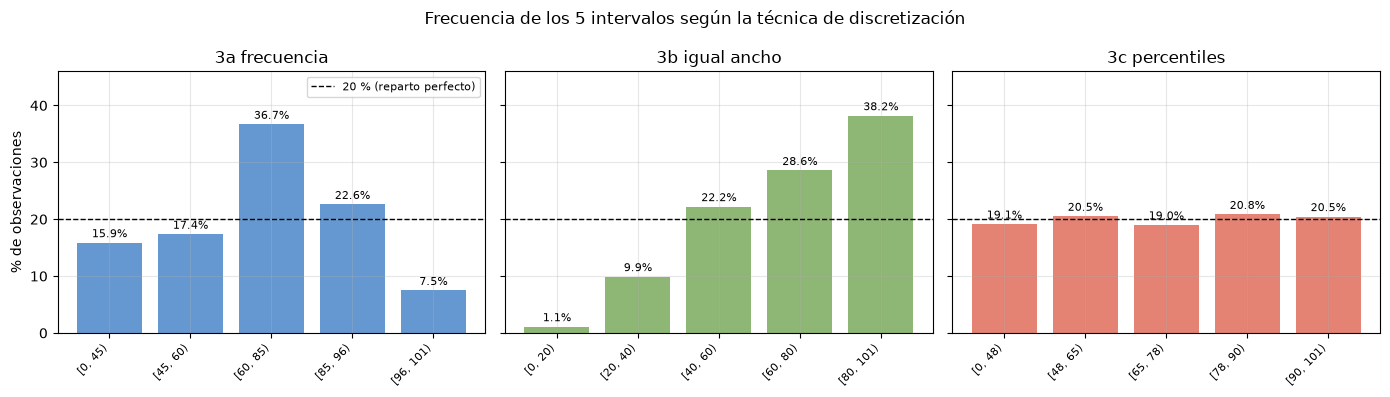

In [47]:
# Un panel por criterio, con el eje y en porcentaje para que los tres se lean en
# la misma escala, y la línea del 20 % como referencia: es lo que daría un
# reparto perfectamente balanceado con cinco rangos.
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
COLORES = ["#4a86c8", "#7aa95c", "#e06c5a"]

for (nombre, col), ax, color in zip(CRIT.items(), axes, COLORES):
    pct = 100 * clima[col].value_counts(normalize=True).sort_index()
    ax.bar(range(5), pct.values, color=color, alpha=0.85)
    ax.axhline(20, color="black", ls="--", lw=1, label="20 % (reparto perfecto)")
    ax.set_xticks(range(5))
    ax.set_xticklabels([str(i) for i in pct.index], rotation=45, ha="right", fontsize=8)
    ax.bar_label(ax.containers[0], fmt="%.1f%%", fontsize=8, padding=2)
    ax.set_title(nombre)
    ax.set_ylim(0, 46)

axes[0].set_ylabel("% de observaciones")
axes[0].legend(fontsize=8)
fig.suptitle("Frecuencia de los 5 intervalos según la técnica de discretización")
fig.tight_layout()
plt.show()

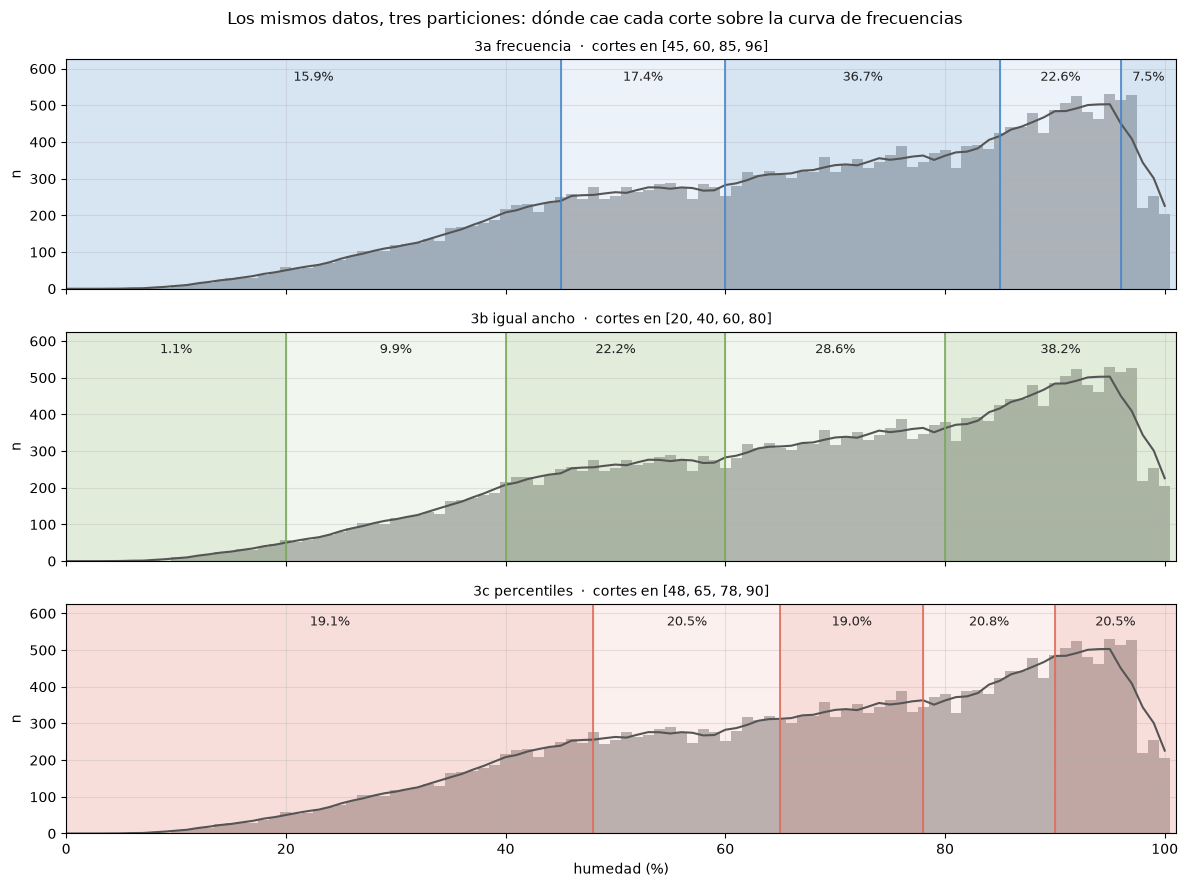

In [48]:
# Los tres gráficos de arriba muestran el reparto pero no por qué sale así. Acá
# superpongo los cortes de cada criterio sobre la curva de frecuencias del 3a:
# las bandas son los cinco rangos y el número es el porcentaje que se lleva cada
# uno. Mismo eje x en los tres paneles, así que las bandas son comparables.
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
suave = frec.rolling(5, center=True, min_periods=1).mean()

for (nombre, col), ax, color, cortes in zip(
        CRIT.items(), axes, COLORES, [CORTES, CORTES_ANCHO, CORTES_PCT]):
    ax.bar(frec.index, frec.values, width=1.0, color="#b8b8b8")
    ax.plot(frec.index, suave, color="#555555", lw=1.5)
    pct = 100 * clima[col].value_counts(normalize=True).sort_index()
    for i, (a, b) in enumerate(zip(cortes[:-1], cortes[1:])):
        ax.axvspan(a, b, color=color, alpha=0.10 if i % 2 else 0.22)
        ax.axvline(a, color=color, lw=1.2)
        ax.text((a + b) / 2, frec.max() * 1.07, f"{pct.iloc[i]:.1f}%",
                ha="center", fontsize=9, color="#222222")
    ax.set_title(f"{nombre}  ·  cortes en {cortes[1:-1]}", fontsize=10)
    ax.set_ylabel("n")
    ax.set_ylim(0, frec.max() * 1.18)

axes[-1].set_xlabel("humedad (%)")
axes[-1].set_xlim(0, 101)
fig.suptitle("Los mismos datos, tres particiones: "
             "dónde cae cada corte sobre la curva de frecuencias")
fig.tight_layout()
plt.show()

In [49]:
from itertools import combinations

# Consistencia como orden: si un registro cae en un rango más alto que otro según
# un criterio, ¿cae igual o empatado según los demás? Para que hubiera una
# inversión, el rango más alto alcanzado dentro de un tramo tendría que superar
# al más bajo del tramo siguiente. Lo verifico en los tres pares.
codigos = pd.DataFrame({n: clima[c].cat.codes.where(clima[c].notna())
                        for n, c in CRIT.items()})

for a, b in combinations(CRIT, 2):
    g = codigos.groupby(codigos[a])[b].agg(["min", "max"])
    inversiones = int((g["max"].values[:-1] > g["min"].values[1:]).sum())
    print(f"{a:16s} vs {b:16s} inversiones: {inversiones}")

# El cruce de los dos criterios más distintos entre sí. Si no hay inversiones,
# los valores distintos de cero tienen que formar una escalera.
print("\nCruce 3b igual ancho (filas) x 3c percentiles (columnas):")
display(pd.crosstab(clima.hum_ancho, clima.hum_pct))

# Consistencia como etiqueta: en cuántas filas los dos criterios le asignan el
# mismo número de rango. Es otra pregunta, y da bien distinto.
print()
for a, b in combinations(CRIT, 2):
    par = codigos[[a, b]].dropna()
    print(f"{a:16s} vs {b:16s} mismo número de rango en el "
          f"{100 * (par[a] == par[b]).mean():.1f} % de las filas")

3a frecuencia    vs 3b igual ancho   inversiones: 0
3a frecuencia    vs 3c percentiles   inversiones: 0
3b igual ancho   vs 3c percentiles   inversiones: 0

Cruce 3b igual ancho (filas) x 3c percentiles (columnas):


hum_pct,"[0, 48)","[48, 65)","[65, 78)","[78, 90)","[90, 101)"
hum_ancho,,,,,
"[0, 20)",255,0,0,0,0
"[20, 40)",2281,0,0,0,0
"[40, 60)",1871,3242,0,0,0
"[60, 80)",0,1481,4376,717,0
"[80, 101)",0,0,0,4081,4710



3a frecuencia    vs 3b igual ancho   mismo número de rango en el 8.6 % de las filas
3a frecuencia    vs 3c percentiles   mismo número de rango en el 66.1 % de las filas
3b igual ancho   vs 3c percentiles   mismo número de rango en el 24.7 % de las filas


**El balanceo**

Los tres criterios parten la misma variable en cinco rangos y reparten las 23.014
observaciones de manera muy distinta. Igual ancho es el más desparejo: 1,1 % en el
primer rango contra 38,2 % en el último, 34,5x, entropía 83,18 %. Percentiles es el
más parejo: entre 19,0 % y 20,8 %, 1,10x, entropía 99,95 %. El del 3a queda en el
medio, 4,9x y 92,83 %.

El gráfico de la celda 3 muestra de dónde sale ese orden. Lo que decide el reparto es
dónde caen los cortes respecto de la altura de la curva. Igual ancho los pone a
distancias iguales sobre el eje x, y como la curva es baja a la izquierda y alta a la
derecha, los rangos de la izquierda quedan casi vacíos. Percentiles hace lo
contrario: los cortes se van juntando hacia la derecha (48, 65, 78 y 90, o sea
separaciones de 17, 13 y 12) porque ahí la curva es alta y con pocos puntos de humedad
ya se junta el 20 %. El del 3a sigue la forma de la curva pero no la compensa, y por
eso cae en el medio.

La conclusión es que el balanceo no es una propiedad de la variable, es una
consecuencia de dónde puse los cortes. El 3c está balanceado por construcción, y lo
estaría con cualquier variable. El 3b está desbalanceado porque la variable es
asimétrica, y ese desbalance es información: dice que la humedad baja es rara en este
dataset. El 3a está algo balanceado como efecto secundario, no porque lo buscara.

Aun así el 3c no llega al 20 % exacto, tiene 99,95 % de entropía y no 100 %. El motivo
son los empates que vi en ese punto. Con una variable entera y cientos de registros
por valor, los grupos exactamente iguales no existen.

**La consistencia**

Depende de qué se pregunte, y las dos medidas de la celda 4 dan cosas opuestas.

Como orden son totalmente consistentes: 0 inversiones en los tres pares. No hay dos
registros que un criterio ordene al revés que otro. Era esperable, porque los tres son
cortes monótonos de la misma variable, así que lo único que puede pasar es que dos
registros que un criterio separa, otro los junte. El cruce lo muestra como una
escalera: cada rango de igual ancho cae en uno, dos o tres rangos de percentiles
contiguos, nunca salteando uno.

Como etiqueta no son consistentes. El número de rango coincide en el 24,7 % de las
filas entre 3b y 3c, y en apenas el 8,6 % entre 3a y 3b. El "rango 3" de un criterio
no es el "rango 3" de otro, así que no se pueden mezclar. Una humedad de 85 es rango 5
por igual ancho y rango 4 por los otros dos.

Como descripción tampoco. Si miro solo el gráfico del 3b concluyo que la humedad se
concentra en valores altos. Si miro solo el del 3c concluyo que está repartida pareja.
La segunda lectura es falsa, y no porque el cálculo esté mal: el criterio impone el
reparto. El gráfico de frecuencias de una discretización por percentiles no dice nada
sobre la distribución de la variable, solo confirma que los percentiles funcionan.


## Ejercicio 4 — Normalización

### Entrada en calor

> Para el dominio E = {1, 5, 9, 17, 18, 34, 45, 89, 99}, ¿cuál sería el valor de
> escalado decimal para 65? ¿Y si utilizo mínimo-máximo?

**Escalado decimal.** El máximo absoluto de E es 99. Con j = 1 el máximo normalizado
sería 9,9, que no es menor que 1, así que j = 2 y el divisor es 100. Entonces
65 / 100 = **0,65**.

**Mínimo-máximo.** Con mín = 1 y máx = 99, el recorrido es 98:
(65 − 1) / 98 = 64 / 98 = **0,6531**.

Los dos resultados son casi iguales, pero es casualidad de este conjunto. El recorrido
da 98 y el divisor del escalado decimal da 100, así que las dos cuentas están dividiendo
por casi lo mismo. No es una propiedad de las técnicas.

Se ve cambiando un solo elemento. Si el máximo fuera 100 en lugar de 99, mínimo-máximo
daría 64 / 99 = 0,6465, casi sin moverse. El escalado decimal, en cambio, salta a j = 3
y da 65 / 1000 = 0,065, diez veces menos. El escalado decimal solo puede dividir por
potencias de 10, así que cruzar el 100 le cuesta un factor entero.

Aparte, el 65 no pertenece a E. Los parámetros de las dos técnicas se estiman sobre E y
se aplican a un valor nuevo, que es el uso normal. Conviene tener presente que con
mínimo-máximo un valor nuevo fuera del rango de E se sale de [0, 1], porque la fórmula
no lo acota, lo acota el conjunto con el que se calcularon los parámetros.

### 4a. Mínimo-máximo

> Normalice el atributo utilizando la técnica de mínimo-máximo.

In [50]:
# Mínimo-máximo al rango [0, 1]. Los parámetros son el mínimo y el máximo
# globales, calculados sobre las 23.019 filas: si los calculara por temporada,
# las cuatro temporadas quedarían con el mismo rango y el punto e no podría
# comparar nada.
VARS_N = ["temperatura", "vel_viento"]

par_mm = {}
for v in VARS_N:
    mn, mx = clima[v].min(), clima[v].max()
    par_mm[v] = (mn, mx)
    clima[f"{v}_mm"] = (clima[v] - mn) / (mx - mn)

display(pd.DataFrame({
    "mín original": [par_mm[v][0] for v in VARS_N],
    "máx original": [par_mm[v][1] for v in VARS_N],
    "recorrido": [par_mm[v][1] - par_mm[v][0] for v in VARS_N],
    "mín normalizado": [clima[f"{v}_mm"].min() for v in VARS_N],
    "máx normalizado": [clima[f"{v}_mm"].max() for v in VARS_N],
    "media normalizada": [clima[f"{v}_mm"].mean() for v in VARS_N],
}, index=VARS_N).round(4))

# Control: la media normalizada no cae en 0,5 salvo que la variable sea
# simétrica. Comparo dónde quedó la media contra dónde quedó la mediana.
for v in VARS_N:
    print(f"{v:12s} media {clima[f'{v}_mm'].mean():.4f}  |  "
          f"mediana {clima[f'{v}_mm'].median():.4f}")

,mín original,máx original,recorrido,mín normalizado,máx normalizado,media normalizada
temperatura,-26.0,42.6,68.6,0.0,1.0,0.614
vel_viento,0.0,100.0,100.0,0.0,1.0,0.135


temperatura  media 0.6139  |  mediana 0.6210
vel_viento   media 0.1350  |  mediana 0.1100


Los parámetros son el mínimo y el máximo globales: temperatura de −26 a 42,6, con un
recorrido de 68,6 grados, y vel_viento de 0 a 100. Las dos variables quedan exactamente
en [0, 1], porque la técnica fuerza ese rango por construcción.

Lo único que sobrevive de la forma de la distribución es dónde cae la media dentro del
intervalo, y ahí las dos no se parecen: 0,614 en temperatura y 0,135 en vel_viento.
Ninguna cae en 0,5. En vel_viento la media queda pegada al piso porque el máximo de 100
km/h está muy lejos del centro de la variable, así que el 0,135 no dice que la velocidad
sea baja, dice que el máximo es alto.

El control de media contra mediana apunta a lo mismo. En temperatura dan 0,6139 y
0,6210, casi iguales. En vel_viento dan 0,1350 y 0,1100, con la media por encima de la
mediana, que es la asimetría positiva que ya había visto en el ejercicio 2.

Anoto un riesgo de la técnica: los dos parámetros son valores extremos, y en las dos
variables el máximo es un único registro. Un solo dato define la escala de toda la
columna.

### 4b. Z-score

> Ahora, normalice el atributo mediante la técnica de z-score.

In [51]:
# Z-score: resto la media y divido por el desvío. Uso el desvío muestral, que es
# el default de pandas (ddof=1); con 23.019 filas la diferencia con el
# poblacional es despreciable, pero lo dejo dicho para que el número sea
# reproducible.
par_z = {}
for v in VARS_N:
    mu, sd = clima[v].mean(), clima[v].std()
    par_z[v] = (mu, sd)
    clima[f"{v}_z"] = (clima[v] - mu) / sd

display(pd.DataFrame({
    "media original": [par_z[v][0] for v in VARS_N],
    "desvío original": [par_z[v][1] for v in VARS_N],
    "media z": [clima[f"{v}_z"].mean() for v in VARS_N],
    "desvío z": [clima[f"{v}_z"].std() for v in VARS_N],
    "mín z": [clima[f"{v}_z"].min() for v in VARS_N],
    "máx z": [clima[f"{v}_z"].max() for v in VARS_N],
}, index=VARS_N).round(4))

# A diferencia de mínimo-máximo, el z-score no acota el rango: los extremos
# quedan donde los deje la relación entre la distancia a la media y el desvío.
print("\ncuántos desvíos ocupa cada variable después del z-score:")
for v in VARS_N:
    print(f"  {v:12s} de {clima[f'{v}_z'].min():.2f} a {clima[f'{v}_z'].max():.2f}")

,media original,desvío original,media z,desvío z,mín z,máx z
temperatura,16.111,8.960,-0.0,1.0,-4.70,2.956
vel_viento,13.505,10.003,0.0,1.0,-1.35,8.647



cuántos desvíos ocupa cada variable después del z-score:
  temperatura  de -4.70 a 2.96
  vel_viento   de -1.35 a 8.65


Los parámetros acá son la media y el desvío: 16,111 y 8,960 en temperatura, 13,505 y
10,003 en vel_viento. Las dos columnas quedan con media 0 y desvío 1, otra vez por
construcción.

La diferencia con mínimo-máximo es que el z-score no acota el rango. Temperatura queda
entre −4,70 y 2,96 desvíos, y vel_viento entre −1,35 y 8,65. Los dos rangos son
asimétricos y para lados opuestos: temperatura se estira hacia abajo y vel_viento hacia
arriba. Es lo mismo que vi en el 2a, donde temperatura tenía 249 outliers bajos contra
9 altos y vel_viento tenía 659, todos altos.

El −1,35 de vel_viento no es casual. La variable no puede bajar de 0, así que su mínimo
normalizado es exactamente la distancia de la media al cero medida en desvíos:
13,505 / 10,003 = 1,35. Con una variable acotada en cero, el z-score no puede bajar más
que eso.

Hay algo que queda dando vueltas. El desvío con el que divido se calculó incluyendo los
outliers, y en el 2c vi que sacándolos el desvío de vel_viento baja un 24,1 %. Así que
el denominador del z-score está agrandado por las mismas observaciones que después mide.

### 4c. Escalado decimal

> Por último, utilice la técnica de escalado decimal para llevar adelante la
> tarea de normalización.

In [52]:
# Escalado decimal: divido por la potencia de 10 más chica que deja el máximo
# absoluto por debajo de 1, estricto. Con máximo absoluto m, ese exponente es
# floor(log10(m)) + 1: para m = 42,6 da 2 porque 4,26 todavía no es menor que 1.
par_dec = {}
for v in VARS_N:
    m = clima[v].abs().max()
    j = int(np.floor(np.log10(m))) + 1
    par_dec[v] = (m, j)
    clima[f"{v}_dec"] = clima[v] / 10 ** j

display(pd.DataFrame({
    "máx absoluto": [par_dec[v][0] for v in VARS_N],
    "j": [par_dec[v][1] for v in VARS_N],
    "divisor": [10 ** par_dec[v][1] for v in VARS_N],
    "mín dec": [clima[f"{v}_dec"].min() for v in VARS_N],
    "máx dec": [clima[f"{v}_dec"].max() for v in VARS_N],
    "recorrido ocupado": [clima[f"{v}_dec"].max() - clima[f"{v}_dec"].min() for v in VARS_N],
}, index=VARS_N).round(4))

# El divisor depende de un solo valor, el máximo absoluto. Miro de qué observación
# se trata en cada variable y qué pasaría con j si esa observación no estuviera.
print("\nde qué depende el divisor:")
for v in VARS_N:
    m = par_dec[v][0]
    fila = clima.loc[clima[v].abs().idxmax()]
    segundo = clima[v].abs().nlargest(2).iloc[-1]
    j_sin = int(np.floor(np.log10(segundo))) + 1
    print(f"  {v:12s} máx |{m:g}| en {fila.estacion_meteorologica} "
          f"({fila.fecha.date()} {int(fila.hora)}h), n={int((clima[v].abs() == m).sum())}")
    print(f"  {'':12s} segundo máximo |{segundo:g}| -> j sería {j_sin} en lugar de {par_dec[v][1]}")

,máx absoluto,j,divisor,mín dec,máx dec,recorrido ocupado
temperatura,42.6,2,100,-0.26,0.426,0.686
vel_viento,100.0,3,1000,0.00,0.100,0.100



de qué depende el divisor:
  temperatura  máx |42.6| en SANTIAGO DEL ESTERO AERO (2025-12-20 16h), n=1
               segundo máximo |42.5| -> j sería 2 en lugar de 2
  vel_viento   máx |100| en BASE MARAMBIO (2026-05-10 3h), n=1
               segundo máximo |93| -> j sería 2 en lugar de 3


Acá el único parámetro es el máximo absoluto. En temperatura es 42,6, así que j = 2 y el
divisor es 100. En vel_viento es 100, así que j = 3 y el divisor es 1000.

Es la única de las tres técnicas que no traslada la variable, solo la divide. Por eso es
la única que conserva el signo y el cero original: las 814 temperaturas bajo cero siguen
siendo negativas y los 1.067 registros de viento en calma siguen valiendo 0. Con
mínimo-máximo el −26 pasa a ser 0 y el cero de viento también pasa a ser 0, o sea que
dos ceros que significan cosas distintas quedan indistinguibles.

Lo que se paga es que no lleva a un rango fijo. Temperatura ocupa 0,686 del intervalo
disponible y vel_viento apenas 0,100. Las dos columnas están en [−1, 1] pero no en la
misma escala, así que no se pueden comparar entre sí como sí se puede con las versiones
de mínimo-máximo.

El caso de vel_viento merece el detalle. El divisor lo decide un solo registro: los 100
km/h de Base Marambio del 10 de mayo de 2026 a las 3 de la mañana. El segundo valor más
alto es 93. Si ese único registro no estuviera, j sería 2, el divisor 100, y la variable
ocuparía 0,93 del intervalo en lugar de 0,100. Un dato entre 23.017 multiplica por diez
o divide por diez a toda la columna. Es exactamente el salto de la entrada en calor con
el 100 en lugar del 99, ahora con datos reales.

### 4d. Comparación de los tres métodos

> Analice los resultados encontrados. Compare los mismos realizando gráficos
> sobre los valores originales y además los atributos resultantes en cada caso.

In [53]:
# Las cuatro versiones de cada variable, una fila por versión. Agrego la
# asimetría porque es la prueba numérica de lo que se ve en los gráficos: las
# tres técnicas son transformaciones lineales con escala positiva, así que no
# pueden cambiar la forma de la distribución.
VERS = {"original": "", "mínimo-máximo": "_mm", "z-score": "_z", "escalado decimal": "_dec"}

filas = []
for v in VARS_N:
    for nombre, suf in VERS.items():
        s = clima[f"{v}{suf}"]
        filas.append({
            "variable": v, "versión": nombre,
            "mín": s.min(), "máx": s.max(), "recorrido": s.max() - s.min(),
            "media": s.mean(), "desvío": s.std(),
            "asimetría": stats.skew(s.dropna()),
        })
comp_n = pd.DataFrame(filas).set_index(["variable", "versión"]).round(4)
display(comp_n)

print("asimetría por variable, ¿cambia entre versiones?")
for v in VARS_N:
    a = comp_n.loc[v, "asimetría"]
    print(f"  {v:12s} {list(a.round(6))}  ->  rango de variación {a.max() - a.min():.2e}")

mín      máx  recorrido   media  desvío  \
variable    versión                                                       
temperatura original         -26.00   42.600     68.600  16.111   8.960   
            mínimo-máximo      0.00    1.000      1.000   0.614   0.131   
            z-score           -4.70    2.956      7.656  -0.000   1.000   
            escalado decimal  -0.26    0.426      0.686   0.161   0.090   
vel_viento  original           0.00  100.000    100.000  13.505  10.003   
            mínimo-máximo      0.00    1.000      1.000   0.135   0.100   
            z-score           -1.35    8.647      9.997   0.000   1.000   
            escalado decimal   0.00    0.100      0.100   0.013   0.010   

                              asimetría  
variable    versión                      
temperatura original             -0.449  
            mínimo-máximo        -0.449  
            z-score              -0.449  
            escalado decimal     -0.449  
vel_viento  original              1.705  
            mínimo-máximo         1.705  
            z-score               1.705  
            escalado decimal      1.705

asimetría por variable, ¿cambia entre versiones?
  temperatura  [-0.4488, -0.4488, -0.4488, -0.4488]  ->  rango de variación 0.00e+00
  vel_viento   [1.7054, 1.7054, 1.7054, 1.7054]  ->  rango de variación 0.00e+00


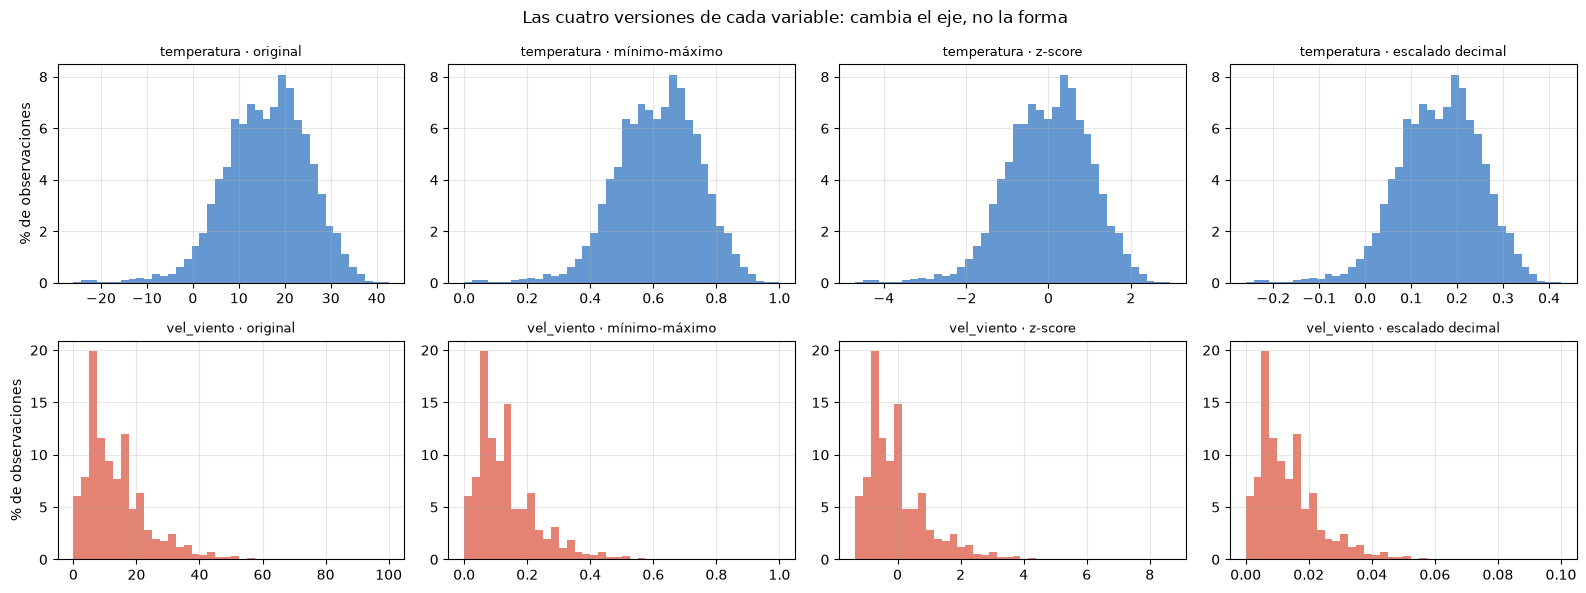

In [54]:
# Una fila por variable, una columna por versión. El eje y está en porcentaje de
# observaciones para que las alturas sean comparables; lo que cambia de panel a
# panel es el eje x, que es justamente lo que hace la normalización.
def pesos(s):
    return np.ones(s.notna().sum()) / s.notna().sum() * 100

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
COL = {"temperatura": "#4a86c8", "vel_viento": "#e06c5a"}

for fila, v in enumerate(VARS_N):
    for col, (nombre, suf) in enumerate(VERS.items()):
        s = clima[f"{v}{suf}"].dropna()
        ax = axes[fila, col]
        ax.hist(s, bins=40, weights=pesos(s), color=COL[v], alpha=0.85)
        ax.set_title(f"{v} · {nombre}", fontsize=9)
        if col == 0:
            ax.set_ylabel("% de observaciones")

fig.suptitle("Las cuatro versiones de cada variable: cambia el eje, no la forma")
fig.tight_layout()
plt.show()

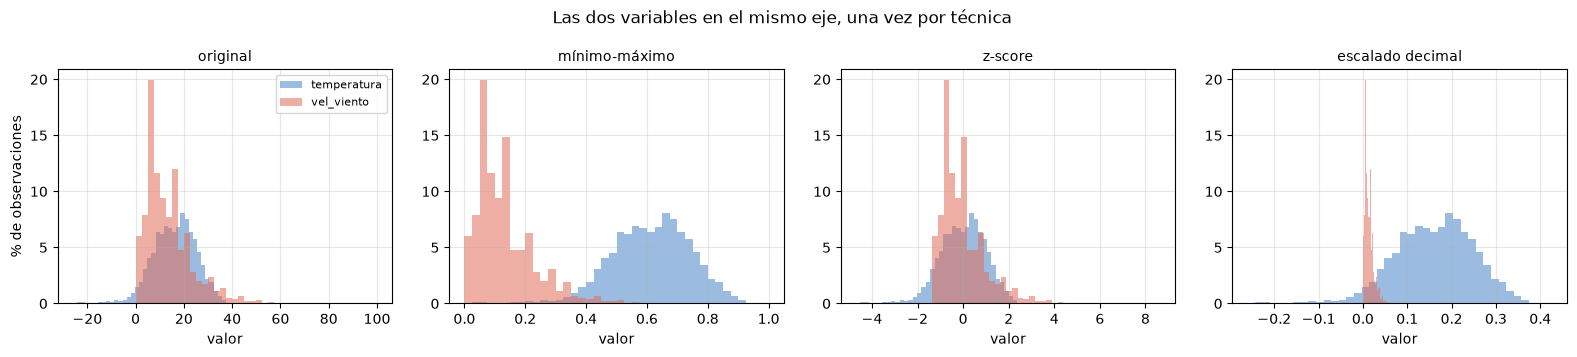

In [55]:
# Ahora las dos variables superpuestas en un mismo eje, un panel por versión.
# Este es el gráfico que muestra para qué sirve normalizar: en unidades
# originales las dos no entran en la misma escala.
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))

for ax, (nombre, suf) in zip(axes, VERS.items()):
    for v in VARS_N:
        s = clima[f"{v}{suf}"].dropna()
        ax.hist(s, bins=40, weights=pesos(s), color=COL[v], alpha=0.55, label=v)
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel("valor")

axes[0].set_ylabel("% de observaciones")
axes[0].legend(fontsize=8)
fig.suptitle("Las dos variables en el mismo eje, una vez por técnica")
fig.tight_layout()
plt.show()

La tabla deja ver qué fija cada técnica y qué no.

Mínimo-máximo fija el recorrido: las dos variables quedan en exactamente 1. Z-score fija
el centro y la unidad, media 0 y desvío 1, pero no el recorrido, que queda en 7,656
desvíos para temperatura y 9,997 para vel_viento. Escalado decimal no fija ninguna de las
dos cosas: solo garantiza que el valor absoluto quede por debajo de 1, y el recorrido que
ocupa cada variable depende de su máximo, 0,686 contra 0,100.

Lo que ninguna de las tres cambia es la forma. La columna de asimetría da −0,4488 en las
cuatro versiones de temperatura y 1,7054 en las cuatro de vel_viento, con un rango de
variación de 0,00e+00, o sea idéntico hasta la precisión de la máquina. Era esperable:
las tres son transformaciones lineales con escala positiva, y una transformación así no
puede mover la asimetría. En la figura de las cuatro versiones se ve igual de claro,
porque los cuatro paneles de cada fila son el mismo dibujo y lo único que cambia son los
números del eje x.

De ahí sale la primera conclusión: normalizar no arregla una distribución torcida ni
elimina outliers. Los 659 outliers de vel_viento del ejercicio 2 siguen estando en las
tres versiones, en la misma posición relativa. Normalizar cambia la escala, no los datos.

La segunda figura muestra para qué sirve entonces. En el panel original las dos
distribuciones aparecen bastante encimadas, pero eso es pura coincidencia de unidades:
los grados centígrados y los kilómetros por hora comparten por casualidad la franja
numérica de 0 a 40, y que se solapen no significa nada. Con mínimo-máximo las dos se
separan, y esa separación sí es información: el eje pasó a medir posición dentro del
recorrido propio de cada variable, así que ahora dice que la temperatura vive en la mitad
alta de su rango (mediana 0,6210) y el viento abajo del suyo (mediana 0,1100). El panel
se lee peor y contiene más.

El de z-score es el único donde las dos quedan centradas en el mismo punto, porque el 0
es la media de cada una. Es la versión que permite preguntar cuál de las dos se aparta
más de lo habitual. El de escalado decimal no logra ninguna de las dos cosas: las dos
variables terminan en escalas distintas, una diez veces más chica que la otra.

### 4e. Boxplots y agrupamiento por temporada

> Repita el análisis utilizando boxplots y además el agrupamiento por la variable
> *temporada*. Compare los resultados obtenidos e indique qué ventajas tiene la
> comparación con las variables normalizadas.

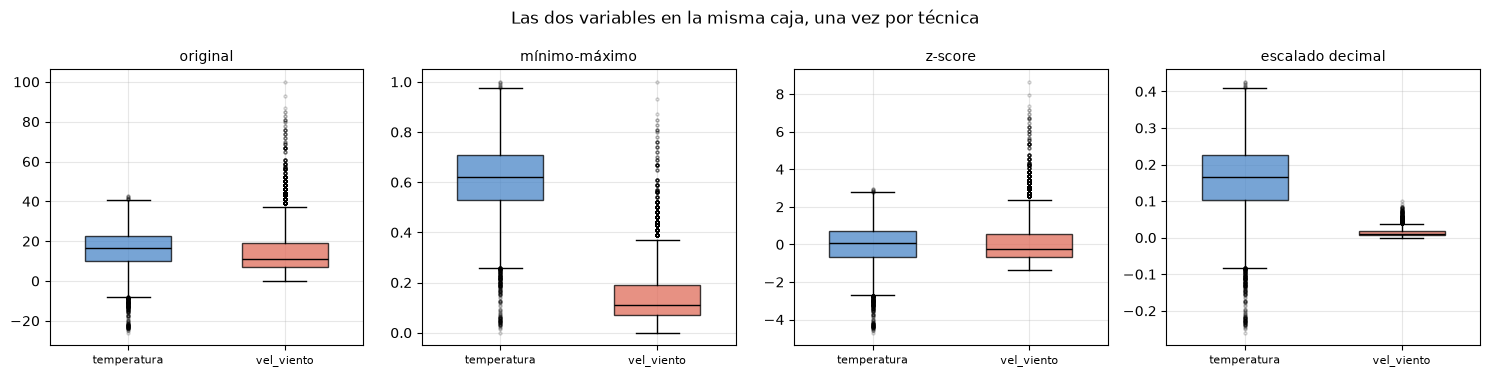

In [56]:
# Los mismos cuatro estados, ahora con boxplots y las dos variables en la misma
# caja. Cada panel tiene su propia escala: no hay forma de dibujar las dos
# variables originales en un eje compartido y que las dos se vean bien.
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))

for ax, (nombre, suf) in zip(axes, VERS.items()):
    datos = [clima[f"{v}{suf}"].dropna() for v in VARS_N]
    bp = ax.boxplot(datos, tick_labels=VARS_N, patch_artist=True, widths=0.55,
                    flierprops={"markersize": 2, "alpha": 0.2})
    for parche, v in zip(bp["boxes"], VARS_N):
        parche.set_facecolor(COL[v]); parche.set_alpha(0.75)
    for mediana in bp["medians"]:
        mediana.set_color("black")
    ax.set_title(nombre, fontsize=10)
    ax.tick_params(axis="x", labelsize=8)

fig.suptitle("Las dos variables en la misma caja, una vez por técnica")
fig.tight_layout()
plt.show()

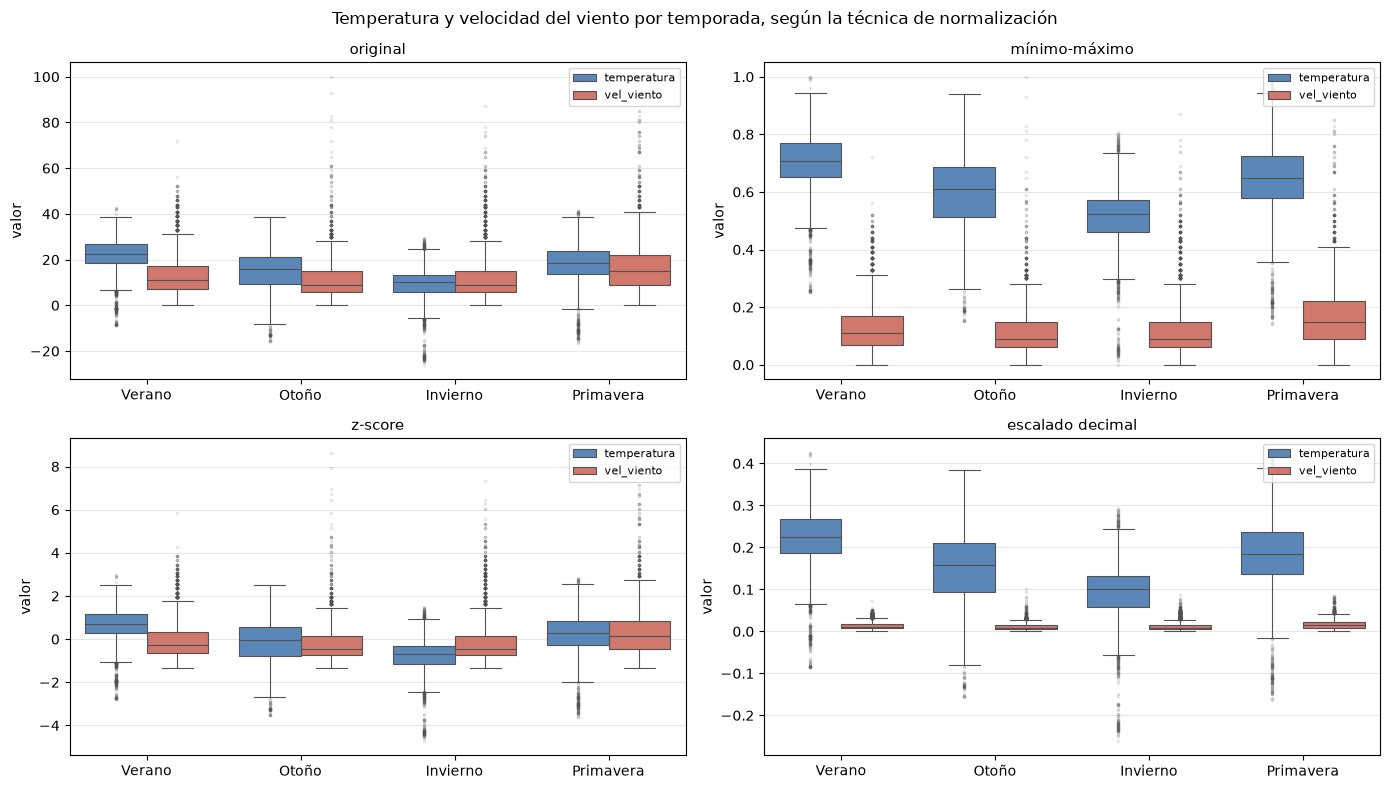

,temperatura (desvíos),vel_viento (desvíos)
temporada,,
Verano,0.713,-0.250
Otoño,-0.029,-0.450
Invierno,-0.682,-0.450
Primavera,0.267,0.149



medianas en unidades originales, para contrastar:


,temperatura,vel_viento
temporada,,
Verano,22.50,11.0
Otoño,15.85,9.0
Invierno,10.00,9.0
Primavera,18.50,15.0


In [57]:
# Agrupamiento por temporada. Paso a formato largo para poder poner temporada en
# el eje x y la variable como color. El orden de las temporadas es el del año, no
# el alfabético, para que la serie se lea como un ciclo.
ORDEN_T = ["Verano", "Otoño", "Invierno", "Primavera"]

largo = []
for nombre, suf in VERS.items():
    for v in VARS_N:
        largo.append(pd.DataFrame({
            "temporada": clima["temporada"], "variable": v,
            "versión": nombre, "valor": clima[f"{v}{suf}"],
        }))
largo = pd.concat(largo, ignore_index=True).dropna(subset=["valor"])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, nombre in zip(axes.ravel(), VERS):
    sns.boxplot(data=largo[largo["versión"] == nombre], x="temporada", y="valor",
                hue="variable", order=ORDEN_T, palette=COL, ax=ax,
                whis=1.5, fliersize=1.5, flierprops={"alpha": 0.15}, linewidth=0.8)
    ax.set_title(nombre, fontsize=11)
    ax.set_xlabel("")
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Temperatura y velocidad del viento por temporada, "
             "según la técnica de normalización")
fig.tight_layout()
plt.show()

# Lo que habilita el eje común: poder leer las dos variables juntas por temporada.
# En z-score la unidad es el desvío, así que los dos números de cada fila se
# pueden comparar entre sí y contra el promedio anual, que es el 0.
tabla_t = (clima.groupby("temporada")[[f"{v}_z" for v in VARS_N]]
           .median().reindex(ORDEN_T).round(3))
tabla_t.columns = ["temperatura (desvíos)", "vel_viento (desvíos)"]
display(tabla_t)

print("\nmedianas en unidades originales, para contrastar:")
display(clima.groupby("temporada")[VARS_N].median().reindex(ORDEN_T).round(2))

Los boxplots dicen lo mismo con otro dibujo, y agregan un detalle práctico.

Con las dos variables en la misma caja, la versión original se puede graficar pero no se
puede leer: una caja está en grados y la otra en kilómetros por hora, así que compararlas
es comparar nada. La versión de escalado decimal es peor todavía, porque la caja de
vel_viento colapsa a una línea. No es un problema del eje: la variable quedó ocupando la
décima parte del espacio que ocupa temperatura, y eso hace que el gráfico deje de servir
aunque los datos estén completos.

En el agrupamiento por temporada aparece la ventaja que pide la consigna. En unidades
originales se ve el ciclo de la temperatura, alta en verano y baja en invierno, y se ve
que el viento casi no se mueve entre temporadas. Eso ya es algo, pero es todo lo que se
puede sacar, porque las dos variables no se pueden poner en la misma pregunta.

Con z-score sí. La tabla de medianas en desvíos da, para temperatura y viento: Verano
0,713 y −0,250, Otoño −0,029 y −0,450, Invierno −0,682 y −0,450, Primavera 0,267 y 0,149.
Ahora los ocho números están en la misma unidad y se pueden leer en las dos direcciones.
Hacia abajo, cuánto se aparta cada temporada del promedio anual del país: Primavera es la
única con viento por encima del promedio. Y de izquierda a derecha, cuál de las dos
variables se aparta más: en verano la temperatura se corre 0,713 desvíos y el viento
0,250, o sea que la temperatura se aparta casi tres veces más. Esa comparación cruzada no
existe en unidades originales.

El caso de Primavera contra Verano lo muestra bien. En unidades originales Primavera tiene
más viento (mediana 15 contra 11) y menos temperatura (18,5 contra 22,5), pero esos
números no dicen si 15 km/h es mucho viento. En desvíos sí: +0,149, apenas por encima del
promedio anual. El salto de 11 a 15 km/h parece grande en la escala del viento y es chico
en la escala de la variable.

Mínimo-máximo también permite el eje común, pero con una referencia más frágil: el 0 y el
1 son el mínimo y el máximo del dataset, y en las dos variables el máximo es un único
registro. Z-score usa la media y el desvío, que son de toda la muestra. Para comparar
grupos me quedo con z-score.

La aclaración final es la misma del 4d. Ninguna de estas tablas tiene información que no
estuviera en los datos originales. Lo que cambia es qué comparaciones se pueden leer sin
equivocarse.